# HCP Sample 2: LR/HR IPF + Encoded LR Irrep Features

This notebook loads **Test sample index 2** from the HCP dataset used in the previous notebook,
then:

1. Plots LR and HR IPF images.
2. Encodes LR quaternions to A1 features.
3. Plots **all encoded LR feature channels** (irrep channels).
4. Plots **irrep norm maps** (total norm + per-irrep-group norms + per-copy norms).

In [22]:
from pathlib import Path
import sys


def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'training').is_dir() and (p / 'models').is_dir() and (p / 'experiments').is_dir():
            return p
    raise FileNotFoundError(
        "Could not find repo root containing training/, models/, and experiments/. "
        f"Started from: {start}"
    )


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATASET_ROOT = Path('/data/warren/materials/EBSD/Ti_Al_1pct_QSR_x4')
EXP_CONFIG = REPO_ROOT / 'experiments/Ti_Al_1pct/iso_embedding_sr_attn_a1_masked_hcp_01/config.json'
CHECKPOINT = REPO_ROOT / 'experiments/Ti_Al_1pct/iso_embedding_sr_attn_a1_masked_hcp_01/checkpoints/best_model.pt'

SPLIT = 'Test'
SAMPLE_INDEX = 2  # sample image 2 from the prior notebook flow
IPF_REF_DIR = 'Z'  # use X, Y, Z, or ALL

print(f'REPO_ROOT:    {REPO_ROOT}')
print(f'DATASET_ROOT: {DATASET_ROOT}')
print(f'EXP_CONFIG:   {EXP_CONFIG}')
print(f'CHECKPOINT:   {CHECKPOINT}')
print(f'SPLIT:        {SPLIT}')
print(f'SAMPLE_INDEX: {SAMPLE_INDEX}')

REPO_ROOT:    /home/warren/projects/Reynolds-QSR
DATASET_ROOT: /data/warren/materials/EBSD/Ti_Al_1pct_QSR_x4
EXP_CONFIG:   /home/warren/projects/Reynolds-QSR/experiments/Ti_Al_1pct/iso_embedding_sr_attn_a1_masked_hcp_01/config.json
CHECKPOINT:   /home/warren/projects/Reynolds-QSR/experiments/Ti_Al_1pct/iso_embedding_sr_attn_a1_masked_hcp_01/checkpoints/best_model.pt
SPLIT:        Test
SAMPLE_INDEX: 2


In [23]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

from training.config_utils import load_and_prepare_config
from training.quaternion_dataset import QuaternionDataset
from utils.runtime_helpers import build_iso_embedding_sr_attn_from_config, load_checkpoint_state_compat
from utils.symmetry_utils import resolve_symmetry
from visualization.ipf_render import render_ipf_rgb


def to_hwc_quat(q: torch.Tensor) -> torch.Tensor:
    if q.dim() != 3:
        raise ValueError(f'Expected rank-3 tensor, got {tuple(q.shape)}')
    if q.shape[-1] == 4:
        return q
    if q.shape[0] == 4:
        return q.permute(1, 2, 0)
    raise ValueError(f'Could not find quaternion channel axis in shape {tuple(q.shape)}')


def normalize_quat(q: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    q = q / torch.linalg.norm(q, dim=-1, keepdim=True).clamp_min(eps)
    q = torch.where(q[..., :1] < 0.0, -q, q)
    return q

In [24]:
assert DATASET_ROOT.exists(), f'Missing dataset root: {DATASET_ROOT}'
assert EXP_CONFIG.exists(), f'Missing config: {EXP_CONFIG}'
assert CHECKPOINT.exists(), f'Missing checkpoint: {CHECKPOINT}'

cfg = load_and_prepare_config(EXP_CONFIG)
cfg.dataset_root = str(DATASET_ROOT)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = build_iso_embedding_sr_attn_from_config(cfg, device=device)
ckpt = torch.load(CHECKPOINT, map_location=device)
state_dict = ckpt.get('model_state_dict', ckpt)
load_checkpoint_state_compat(model, state_dict, context='HCP sample2 notebook checkpoint')
model.eval()

ds = QuaternionDataset(dataset_root=str(DATASET_ROOT), split=SPLIT, preload=False, preload_torch=False)
lr_raw, hr_raw = ds[SAMPLE_INDEX]

lr_hwc = normalize_quat(to_hwc_quat(lr_raw).to(device=device, dtype=torch.float32))
hr_hwc = normalize_quat(to_hwc_quat(hr_raw).to(device=device, dtype=torch.float32))

sym_class = resolve_symmetry(getattr(cfg, 'symmetry_group', 'D6h'))

h_lr, w_lr = int(lr_hwc.shape[0]), int(lr_hwc.shape[1])
h_hr, w_hr = int(hr_hwc.shape[0]), int(hr_hwc.shape[1])

print(f'Loaded sample index: {SAMPLE_INDEX}')
print(f'LR shape (H,W,4): {tuple(lr_hwc.shape)}')
print(f'HR shape (H,W,4): {tuple(hr_hwc.shape)}')
print(f'Encoded feature dim (A1): {int(getattr(model, "feature_dim_a1", -1))}')
print(f'irreps_a1: {getattr(model, "irreps_a1", None)}')

Using symmetry group from config: D6h
Overridden config values:
  - dataset_root: /data/warren/materials/EBSD/Ti_Al_1pct_QSR_x4 (default: )
  - epochs: 50 (default: 10)
  - batch_size: 2 (default: 4)
  - symmetry_group: D6h (default: O)
  - crystal: hcp (default: fcc)
  - use_attention: False (default: True)
  - decoder_num_starts: 8 (default: 2)
  - decoder_steps: 12 (default: 1)
  - decoder_lr: 0.03 (default: 0.05)
  - decoder_table_cache_dir: /home/warren/projects/Reynolds-QSR/out/decoder_lookup_tables (default: out/decoder_lookup_tables)
  - num_workers: 8 (default: 0)
  - preload: True (default: False)
  - preload_torch: True (default: False)
  - min_free_cuda_gb: 4.0 (default: 0.0)
  - model.type: iso_embedding_sr_attn_a1_masked (default: iso_embedding_sr_attn)
Using existing symmetry files for D6h
Using device: cuda
Loaded sample index: 2
LR shape (H,W,4): (32, 32, 4)
HR shape (H,W,4): (128, 128, 4)
Encoded feature dim (A1): 32
irreps_a1: 2x2e+1x4e+1x6e


/tmp/ipykernel_2272455/551494763.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CHECKPOINT, map_location=device)


## LR/HR IPF (Prepared For Combined Figure)

In [25]:
lr_np = lr_hwc.detach().cpu().numpy().astype(np.float32)
hr_np = hr_hwc.detach().cpu().numpy().astype(np.float32)

lr_rgb_raw = render_ipf_rgb(lr_np, sym_class, ref_dir=IPF_REF_DIR)
hr_rgb_raw = render_ipf_rgb(hr_np, sym_class, ref_dir=IPF_REF_DIR)

# Keep one RGB image for combined figure; when ref_dir='ALL', use Z by default.
if isinstance(lr_rgb_raw, list):
    lr_rgb = lr_rgb_raw[2]  # Z
    hr_rgb = hr_rgb_raw[2]  # Z
else:
    lr_rgb = lr_rgb_raw
    hr_rgb = hr_rgb_raw

print(f'Prepared LR/HR IPF images for ref_dir={IPF_REF_DIR}')

Prepared LR/HR IPF images for ref_dir=Z


## Encode LR Features

In [26]:
with torch.no_grad():
    lr_flat = lr_hwc.reshape(h_lr * w_lr, 4)
    feat_lr_flat = model.encode_a1(lr_flat)

feat_lr_img = feat_lr_flat.reshape(h_lr, w_lr, -1)
c_feat = int(feat_lr_img.shape[-1])

print(f'feat_lr_flat shape: {tuple(feat_lr_flat.shape)}')
print(f'feat_lr_img shape:  {tuple(feat_lr_img.shape)}')

# Build channel labels from irreps decomposition
channel_labels = []
irrep_blocks = []
start = 0
for g_idx, (mul, ir) in enumerate(model.irreps_a1):
    mul_i = int(mul)
    dim_i = int(ir.dim)
    n_i = mul_i * dim_i
    irrep_blocks.append({
        'group_index': g_idx,
        'irrep': str(ir),
        'mul': mul_i,
        'dim': dim_i,
        'start': start,
        'end': start + n_i,
    })
    for copy_idx in range(mul_i):
        for comp_idx in range(dim_i):
            channel_labels.append(f'g{g_idx}:{ir} c{copy_idx} d{comp_idx}')
    start += n_i

print('Irrep blocks:')
for b in irrep_blocks:
    print(
        f"  g{b['group_index']}: {b['mul']}x{b['irrep']} "
        f"channels[{b['start']}:{b['end']}]"
    )

feat_lr_flat shape: (1024, 32)
feat_lr_img shape:  (32, 32, 32)
Irrep blocks:
  g0: 2x2e channels[0:10]
  g1: 1x4e channels[10:19]
  g2: 1x6e channels[19:32]


## Separate Figures: LR/HR, L=2 (g0), L=4 (g1), L=6 (g2)

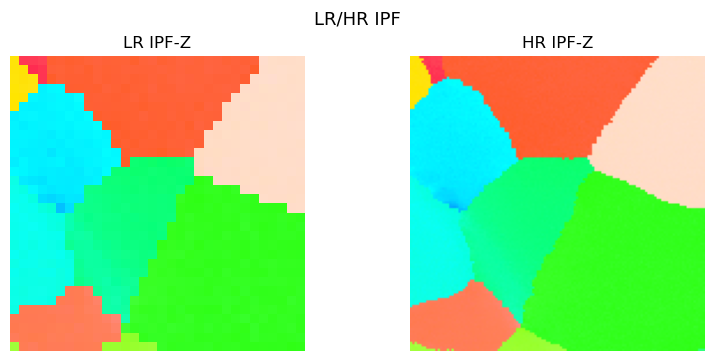

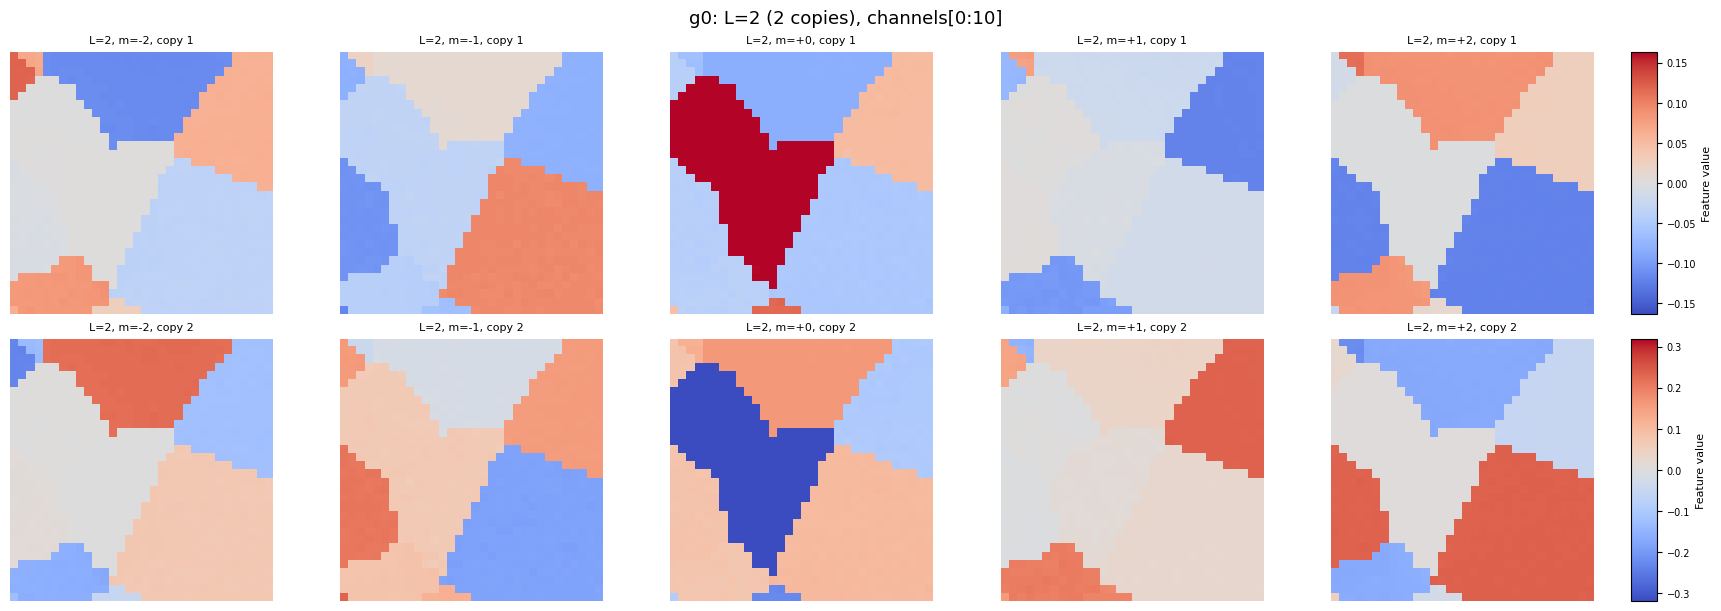

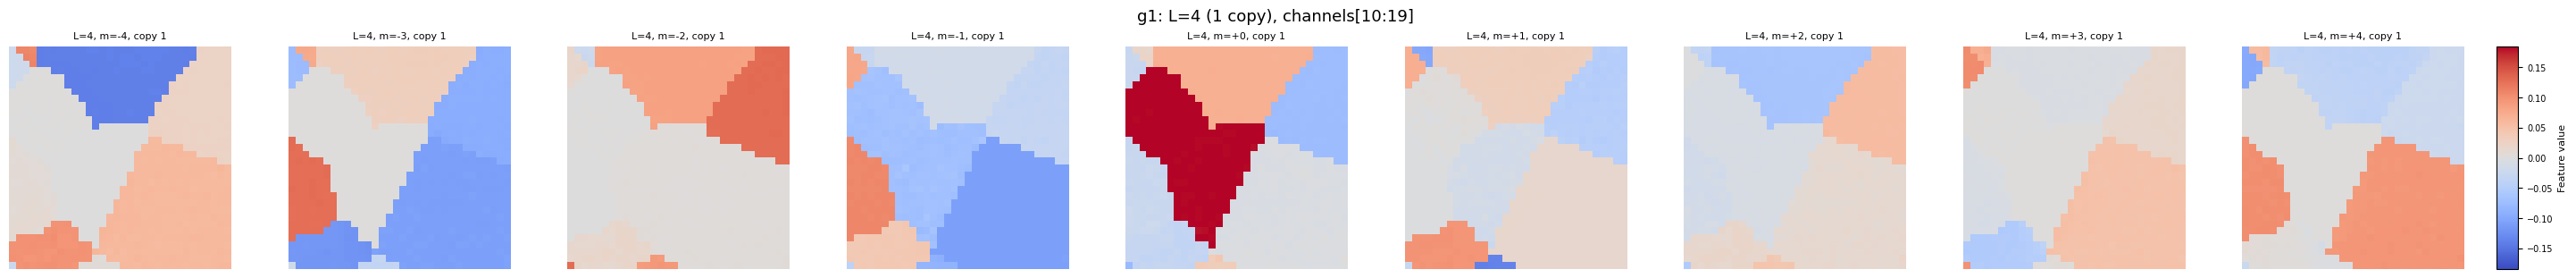

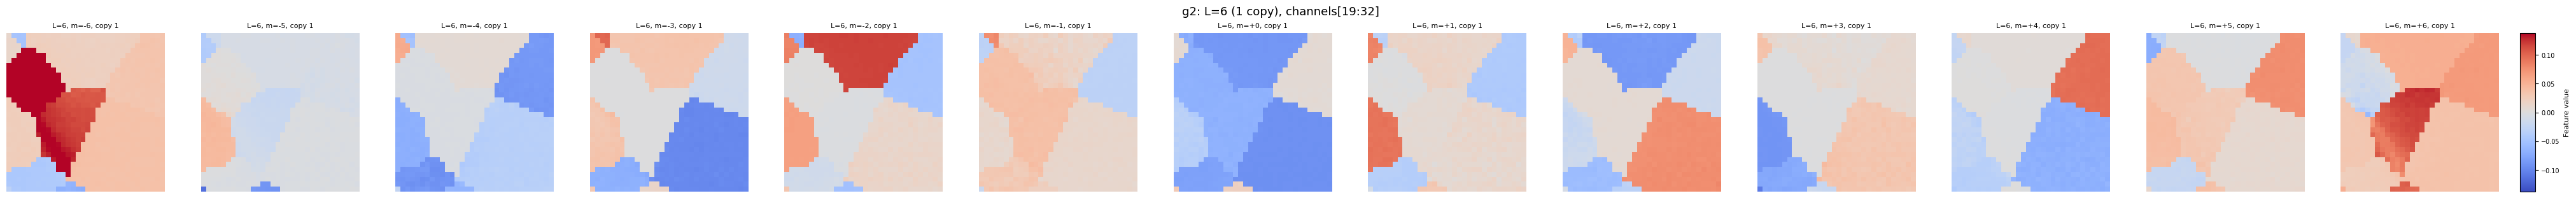

In [27]:
feat_np = feat_lr_img.detach().cpu().numpy()


def plot_irrep_group_with_row_colorbars(block, group_title):
    """
    Plot one figure for an irrep group.
    - One row per copy.
    - One channel map per m component in that row.
    - One shared colorbar for the whole row.
    """
    start = int(block['start'])
    mul = int(block['mul'])
    dim = int(block['dim'])

    # For spherical harmonics-like blocks, dim = 2L + 1
    L = (dim - 1) // 2
    m_vals = list(range(-L, L + 1))

    fig = plt.figure(figsize=(2.9 * (dim + 1), 3.0 * mul), constrained_layout=True)
    gs = fig.add_gridspec(
        nrows=mul,
        ncols=dim + 1,
        width_ratios=[1.0] * dim + [0.08],
    )

    for copy_idx in range(mul):
        row_maps = []
        row_channels = []
        for j in range(dim):
            ch = start + copy_idx * dim + j
            row_channels.append(ch)
            row_maps.append(feat_np[..., ch])

        row_stack = np.stack(row_maps, axis=0)
        vmax = float(np.percentile(np.abs(row_stack), 99.0))
        vmax = max(vmax, 1e-8)

        im_last = None
        for j, ch in enumerate(row_channels):
            ax = fig.add_subplot(gs[copy_idx, j])
            m = m_vals[j]
            title = f"L={L}, m={m:+d}, copy {copy_idx + 1}"
            im_last = ax.imshow(feat_np[..., ch], cmap='coolwarm', vmin=-vmax, vmax=vmax)
            ax.set_title(title, fontsize=8)
            ax.axis('off')

        cax = fig.add_subplot(gs[copy_idx, -1])
        cbar = fig.colorbar(im_last, cax=cax)
        cbar.ax.tick_params(labelsize=7)
        cbar.set_label('Feature value', fontsize=8)

    fig.suptitle(group_title, fontsize=13)
    plt.show()


# Figure 1: small LR/HR IPF figure
fig_lrhr, ax_lrhr = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)
ax_lrhr[0].imshow(lr_rgb)
ax_lrhr[0].set_title(f'LR IPF-{IPF_REF_DIR}')
ax_lrhr[0].axis('off')

ax_lrhr[1].imshow(hr_rgb)
ax_lrhr[1].set_title(f'HR IPF-{IPF_REF_DIR}')
ax_lrhr[1].axis('off')

fig_lrhr.suptitle('LR/HR IPF', fontsize=13)
plt.show()

# Figures 2-4: irrep groups with titles L,m,copy and one colorbar per row
# g0: 2x2e channels[0:10]
plot_irrep_group_with_row_colorbars(
    block=irrep_blocks[0],
    group_title='g0: L=2 (2 copies), channels[0:10]',
)

# g1: 1x4e channels[10:19]
plot_irrep_group_with_row_colorbars(
    block=irrep_blocks[1],
    group_title='g1: L=4 (1 copy), channels[10:19]',
)

# g2: 1x6e channels[19:32]
plot_irrep_group_with_row_colorbars(
    block=irrep_blocks[2],
    group_title='g2: L=6 (1 copy), channels[19:32]',
)

## Total Encoded Feature Norm

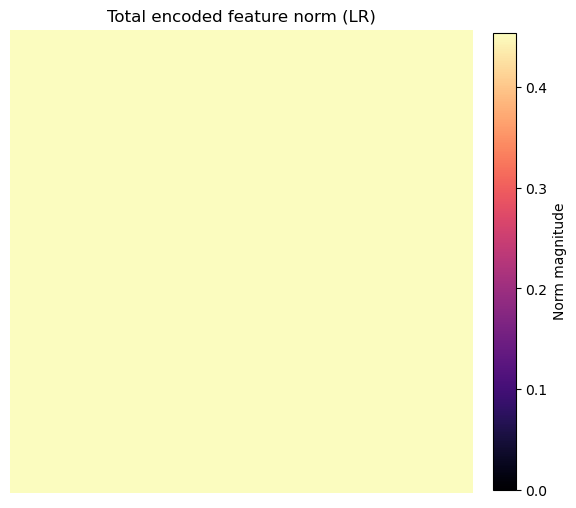

In [28]:
feat_np = feat_lr_img.detach().cpu().numpy()

total_norm = np.linalg.norm(feat_np, axis=-1)

fig, ax = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
vmax = float(np.percentile(total_norm, 99.0))
vmax = max(vmax, 1e-8)

im = ax.imshow(total_norm, cmap='magma', vmin=0.0, vmax=vmax)
ax.set_title('Total encoded feature norm (LR)')
ax.axis('off')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Norm magnitude')

plt.show()

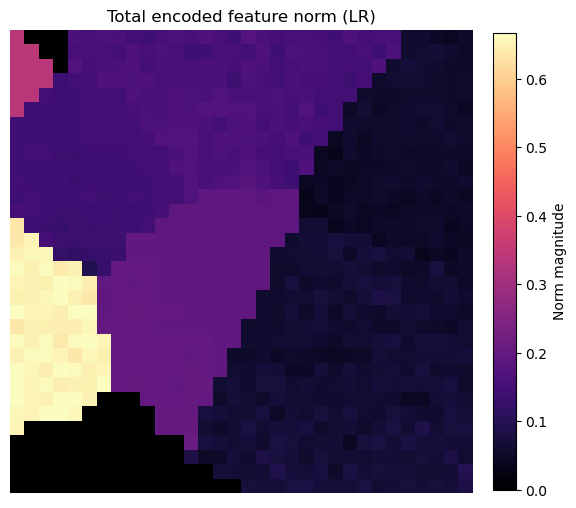

In [29]:
feat_np = feat_lr_img.detach().cpu().numpy()

total_norm = np.sum(feat_np, axis=-1)

fig, ax = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
vmax = float(np.percentile(total_norm, 99.0))
vmax = max(vmax, 1e-8)

im = ax.imshow(total_norm, cmap='magma', vmin=0.0, vmax=vmax)
ax.set_title('Total encoded feature norm (LR)')
ax.axis('off')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Norm magnitude')

plt.show()

Input irreps:  2x2e+1x4e+1x6e
Output irreps: 1x0e
Linear params: weight_numel=0, bias_numel=0
FCTP params:   weight_numel=6
Linear map stats -> min=0, max=0, std=0
FCTP map stats   -> min=0.03217, max=0.03217, std=8.785e-09


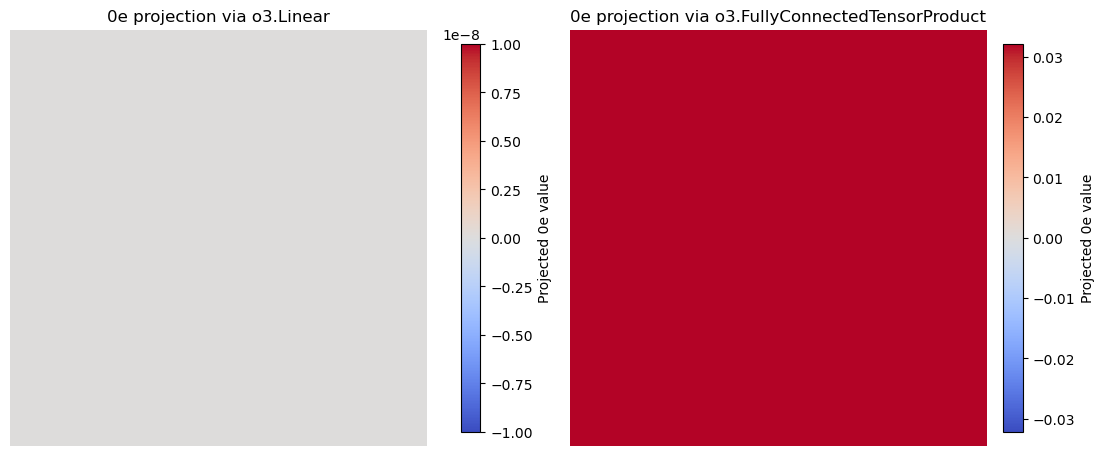

In [30]:
from e3nn import o3

irreps_in = model.irreps_a1
irreps_out = o3.Irreps('1x0e')

torch.manual_seed(0)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(0)

linear_0e = o3.Linear(irreps_in, irreps_out).to(device)
fctp_0e = o3.FullyConnectedTensorProduct(irreps_in, irreps_in, irreps_out).to(device)

with torch.no_grad():
    proj_linear_flat = linear_0e(feat_lr_flat)            # (H*W, 1)
    proj_fctp_flat = fctp_0e(feat_lr_flat, feat_lr_flat)  # (H*W, 1)

proj_linear = proj_linear_flat.reshape(h_lr, w_lr).detach().cpu().numpy()
proj_fctp = proj_fctp_flat.reshape(h_lr, w_lr).detach().cpu().numpy()

print(f'Input irreps:  {irreps_in}')
print(f'Output irreps: {irreps_out}')
print(f'Linear params: weight_numel={getattr(linear_0e, "weight_numel", "n/a")}, bias_numel={getattr(linear_0e, "bias_numel", "n/a")}')
print(f'FCTP params:   weight_numel={getattr(fctp_0e, "weight_numel", "n/a")}')
print(
    f'Linear map stats -> min={proj_linear.min():.4g}, max={proj_linear.max():.4g}, std={proj_linear.std():.4g}'
)
print(
    f'FCTP map stats   -> min={proj_fctp.min():.4g}, max={proj_fctp.max():.4g}, std={proj_fctp.std():.4g}'
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

for ax, arr, title in [
    (axes[0], proj_linear, '0e projection via o3.Linear'),
    (axes[1], proj_fctp, '0e projection via o3.FullyConnectedTensorProduct'),
]:
    vmax = float(np.percentile(np.abs(arr), 99.0))
    vmax = max(vmax, 1e-8)
    im = ax.imshow(arr, cmap='coolwarm', vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Projected 0e value')

plt.show()


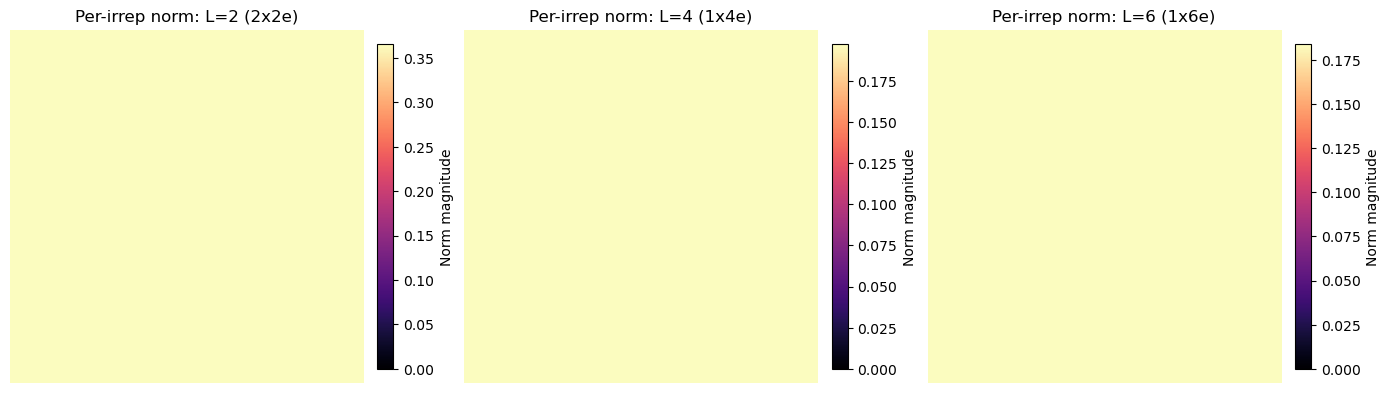

L=2 (2x2e): min=0.3655, max=0.3655, mean=0.3655, std=6.185e-08
L=4 (1x4e): min=0.1974, max=0.1974, mean=0.1974, std=3.891e-08
L=6 (1x6e): min=0.1838, max=0.1838, mean=0.1838, std=3.586e-08


In [31]:
feat_np = feat_lr_img.detach().cpu().numpy()

per_irrep_norm_maps = []
for block in irrep_blocks:
    start = int(block['start'])
    end = int(block['end'])
    mul = int(block['mul'])
    dim = int(block['dim'])
    L = (dim - 1) // 2

    block_feat = feat_np[..., start:end].reshape(h_lr, w_lr, mul, dim)
    # L2 norm over all copies and m-components for this irrep block.
    block_norm = np.linalg.norm(block_feat.reshape(h_lr, w_lr, mul * dim), axis=-1)

    per_irrep_norm_maps.append({
        'L': L,
        'irrep': str(block['irrep']),
        'mul': mul,
        'norm': block_norm,
    })

n = len(per_irrep_norm_maps)
fig, axes = plt.subplots(1, n, figsize=(4.6 * n, 4.2), constrained_layout=True)
if n == 1:
    axes = [axes]

for ax, item in zip(axes, per_irrep_norm_maps):
    arr = item['norm']
    vmax = float(np.percentile(arr, 99.0))
    vmax = max(vmax, 1e-8)

    im = ax.imshow(arr, cmap='magma', vmin=0.0, vmax=vmax)
    ax.set_title(f"Per-irrep norm: L={item['L']} ({item['mul']}x{item['irrep']})")
    ax.axis('off')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Norm magnitude')

plt.show()

for item in per_irrep_norm_maps:
    arr = item['norm']
    print(
        f"L={item['L']} ({item['mul']}x{item['irrep']}): min={arr.min():.4g}, max={arr.max():.4g}, mean={arr.mean():.4g}, std={arr.std():.4g}"
    )


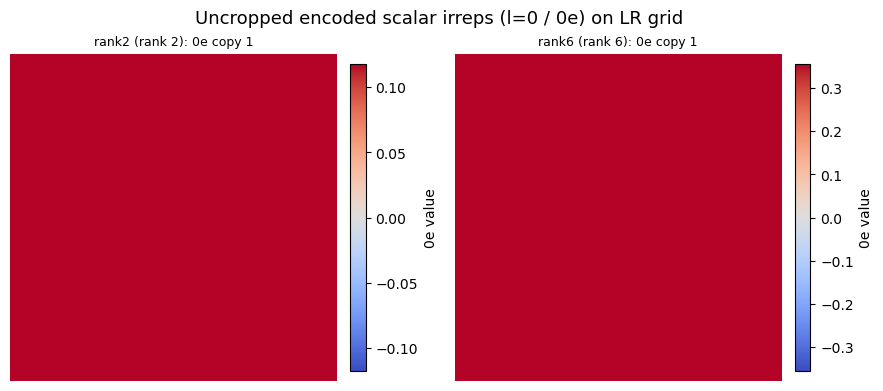

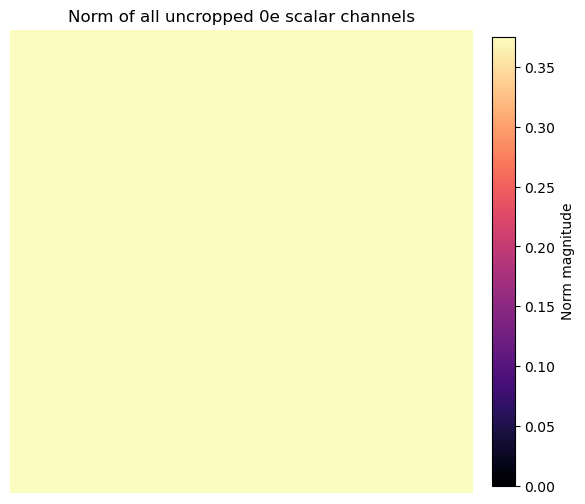

Extracted uncropped scalar channels:
  rank2 rank=2 irrep=0e copy=1: min=0.1179, max=0.1179, std=1.36e-08
  rank6 rank=6 irrep=0e copy=1: min=0.3563, max=0.3563, std=6.464e-08


In [32]:
from e3nn.io import CartesianTensor
from models.local_iso_embedding import full_symmetry_formula, _quat_conjugate, _quat_to_matrix_active

emb = model.encoder.embedding
q_passive = lr_hwc.reshape(-1, 4).to(device=emb.group_mats.device, dtype=emb.group_mats.dtype)
q_active = _quat_conjugate(q_passive)
R_active = _quat_to_matrix_active(q_active)

scalar_maps = []
scalar_meta = []

with torch.no_grad():
    for block in emb.blocks:
        rank = int(block.rank)
        beta = float(block.beta)

        # Build the full (uncropped) Cartesian->irreps projection for this rank.
        formula = full_symmetry_formula(rank)
        ct = CartesianTensor(formula)
        rtp = ct.reduced_tensor_products()
        irreps_with_scalars = rtp.irreps_out.regroup()

        flat_dim = 3 ** rank
        basis = torch.eye(flat_dim, dtype=emb.group_mats.dtype, device=emb.group_mats.device)
        basis_multi = basis.reshape(flat_dim, *([3] * rank))
        proj_with_scalars = ct.from_cartesian(basis_multi).contiguous()

        x_flat = emb._orbit_average_flat(R_active, block.orbit_directions_t, rank)
        y_full_uncropped = beta * (x_flat @ proj_with_scalars)

        for sl, (mul, ir) in zip(irreps_with_scalars.slices(), irreps_with_scalars):
            if int(ir.l) != 0:
                continue
            mul_i = int(mul)
            vals = y_full_uncropped[:, sl].reshape(-1, mul_i, int(ir.dim))
            for copy_idx in range(mul_i):
                # l=0 => dim=1 (scalar), so take component 0
                arr = vals[:, copy_idx, 0].reshape(h_lr, w_lr).detach().cpu().numpy()
                scalar_maps.append(arr)
                scalar_meta.append({
                    'block': str(getattr(block, 'name', f'rank{rank}')),
                    'rank': rank,
                    'irrep': str(ir),
                    'copy': copy_idx + 1,
                })

if len(scalar_maps) == 0:
    print('No l=0 scalar irreps found in uncropped projection.')
else:
    n = len(scalar_maps)
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.8 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for i, (arr, meta) in enumerate(zip(scalar_maps, scalar_meta)):
        ax = axes[i]
        vmax = float(np.percentile(np.abs(arr), 99.0))
        vmax = max(vmax, 1e-8)
        im = ax.imshow(arr, cmap='coolwarm', vmin=-vmax, vmax=vmax)
        ax.set_title(
            f"{meta['block']} (rank {meta['rank']}): {meta['irrep']} copy {meta['copy']}",
            fontsize=9,
        )
        ax.axis('off')
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('0e value')

    for j in range(n, len(axes)):
        axes[j].axis('off')

    fig.suptitle('Uncropped encoded scalar irreps (l=0 / 0e) on LR grid', fontsize=13)
    plt.show()

    scalar_stack = np.stack(scalar_maps, axis=-1)
    scalar_norm = np.linalg.norm(scalar_stack, axis=-1)
    fig, ax = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
    vmax = float(np.percentile(scalar_norm, 99.0))
    vmax = max(vmax, 1e-8)
    im = ax.imshow(scalar_norm, cmap='magma', vmin=0.0, vmax=vmax)
    ax.set_title('Norm of all uncropped 0e scalar channels')
    ax.axis('off')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Norm magnitude')
    plt.show()

    print('Extracted uncropped scalar channels:')
    for meta, arr in zip(scalar_meta, scalar_maps):
        print(
            f"  {meta['block']} rank={meta['rank']} irrep={meta['irrep']} copy={meta['copy']}: "
            f"min={arr.min():.4g}, max={arr.max():.4g}, std={arr.std():.4g}"
        )


pairwise_scalar_lr shape: (64, 32, 32) (S,H,W)


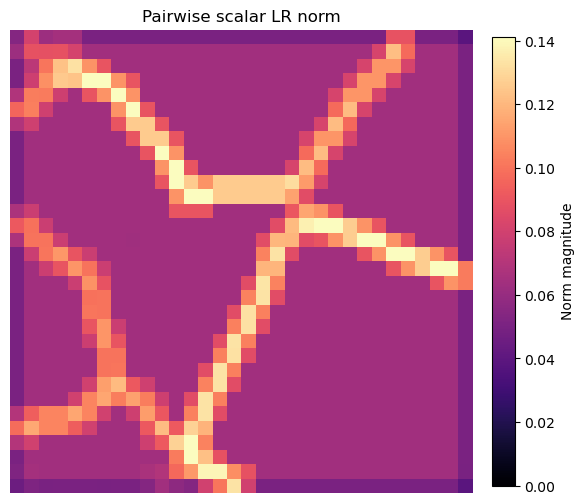

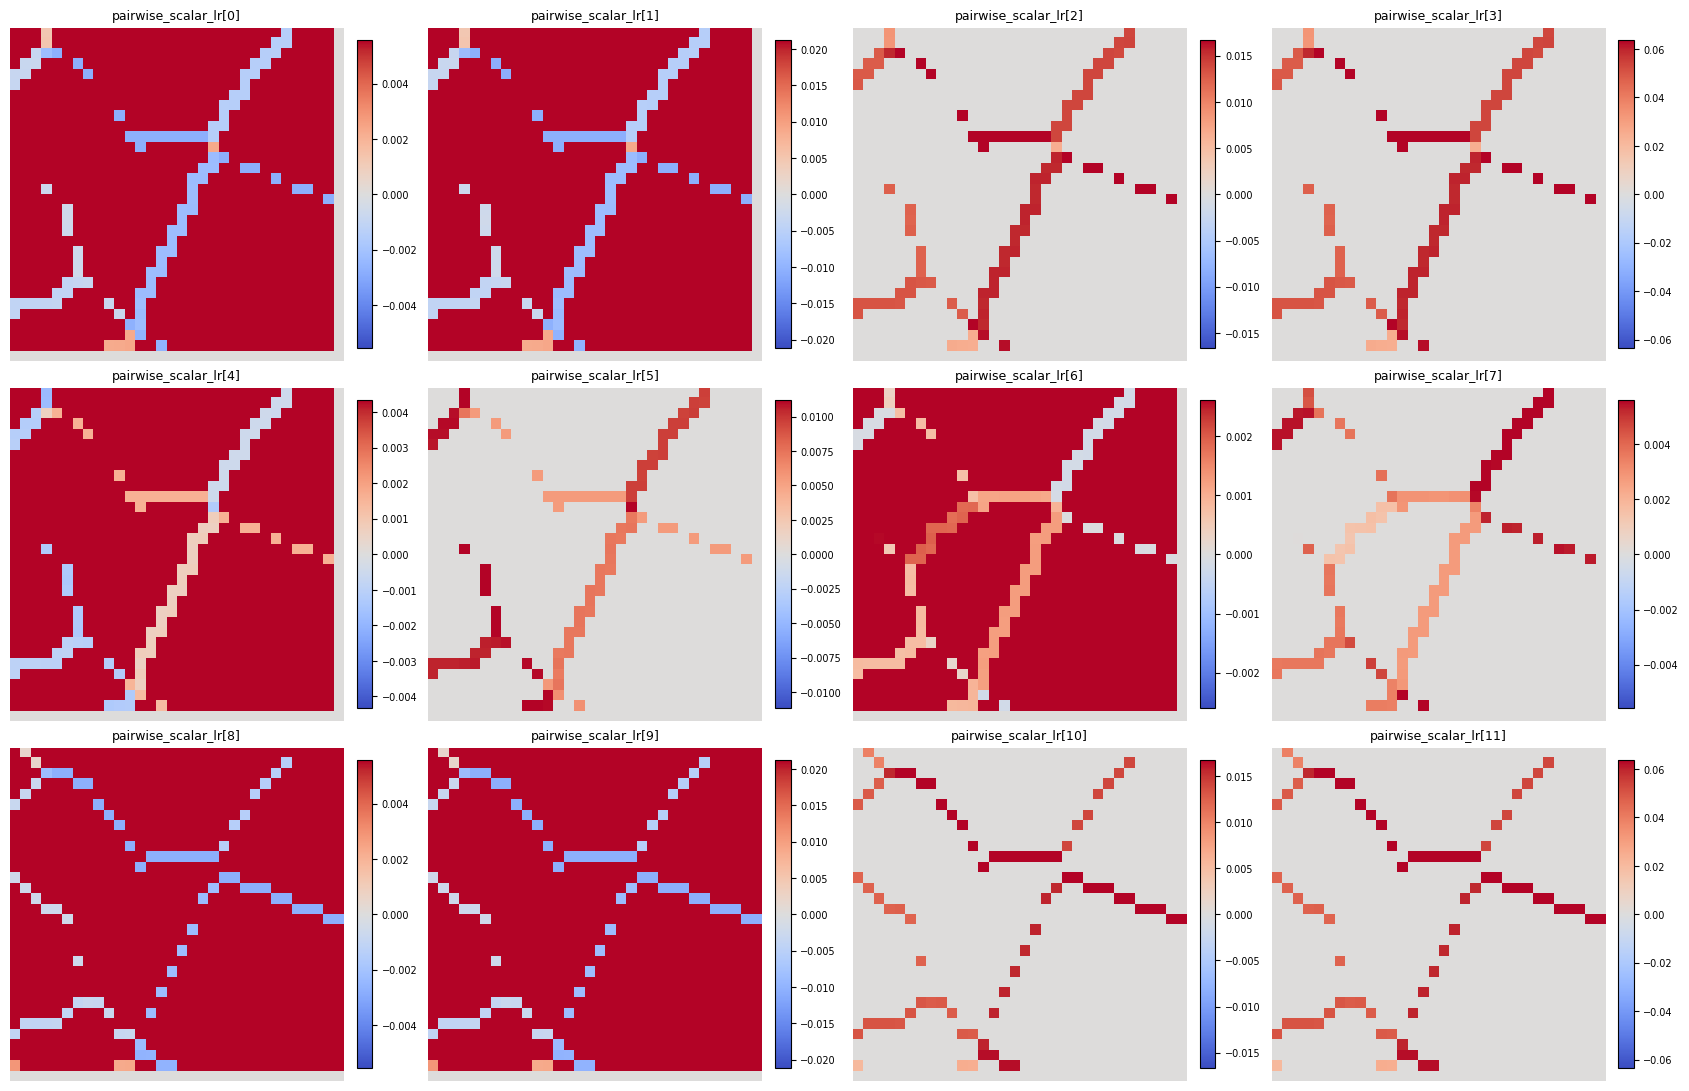

In [33]:
from e3nn.o3 import Irreps

def _pairwise_irrep_neighbor_scalars(
    feat_lr: torch.Tensor,
    lr_shape: tuple[int, int],
    irreps_feat: Irreps | str,
    radius: int = 1,
    include_dot: bool = True,
    include_diff: bool = True,
) -> torch.Tensor:
    """Build spatial pairwise scalar (0e) channels from irrep features."""
    irreps_feat = Irreps(irreps_feat)
    H, W = lr_shape

    batched = feat_lr.dim() == 3
    if not batched:
        feat_lr = feat_lr.unsqueeze(0)

    B, N, C = feat_lr.shape
    if N != H * W:
        raise ValueError(f'Expected N={H * W}, got {N}')
    if C != irreps_feat.dim:
        raise ValueError(f'Expected feature dim {irreps_feat.dim}, got {C}')

    feat_img = feat_lr.reshape(B, H, W, C)

    offsets = []
    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            if dy == 0 and dx == 0:
                continue
            offsets.append((dy, dx))

    center = feat_img
    chans = []

    for dy, dx in offsets:
        neigh = torch.roll(feat_img, shifts=(dy, dx), dims=(1, 2))

        valid = torch.ones((H, W), device=feat_img.device, dtype=feat_img.dtype)
        if dy > 0:
            valid[:dy, :] = 0.0
        elif dy < 0:
            valid[dy:, :] = 0.0
        if dx > 0:
            valid[:, :dx] = 0.0
        elif dx < 0:
            valid[:, dx:] = 0.0
        valid = valid.reshape(1, H, W, 1)

        for sl, mul_ir in zip(irreps_feat.slices(), irreps_feat):
            mul = int(mul_ir.mul)
            d = int(mul_ir.ir.dim)

            fc = center[..., sl].reshape(B, H, W, mul, d)
            fn = neigh[..., sl].reshape(B, H, W, mul, d)

            if include_dot:
                dot = (fc * fn).mean(dim=-1) * valid
                chans.append(dot.permute(0, 3, 1, 2).contiguous())

            if include_diff:
                diff = ((fc - fn) ** 2).mean(dim=-1) * valid
                chans.append(diff.permute(0, 3, 1, 2).contiguous())

    if len(chans) == 0:
        raise ValueError('No scalar channels were constructed.')

    scalar_img = torch.cat(chans, dim=1)
    if not batched:
        scalar_img = scalar_img.squeeze(0)
    return scalar_img

with torch.no_grad():
    pairwise_scalar_lr = _pairwise_irrep_neighbor_scalars(
        feat_lr=feat_lr_flat,
        lr_shape=(h_lr, w_lr),
        irreps_feat=model.irreps_a1,
        radius=1,
        include_dot=True,
        include_diff=True,
    )

if pairwise_scalar_lr.dim() == 4:
    pairwise_scalar_lr = pairwise_scalar_lr.squeeze(0)

pairwise_np = pairwise_scalar_lr.detach().cpu().numpy()
print(f'pairwise_scalar_lr shape: {tuple(pairwise_scalar_lr.shape)} (S,H,W)')

pairwise_norm = np.linalg.norm(pairwise_np, axis=0)
fig, ax = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
vmax = float(np.percentile(pairwise_norm, 99.0))
vmax = max(vmax, 1e-8)
im = ax.imshow(pairwise_norm, cmap='magma', vmin=0.0, vmax=vmax)
ax.set_title('Pairwise scalar LR norm')
ax.axis('off')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Norm magnitude')
plt.show()

n_display = min(12, int(pairwise_np.shape[0]))
ncols = 4
nrows = (n_display + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.6 * nrows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for i in range(n_display):
    ax = axes[i]
    arr = pairwise_np[i]
    vmax = float(np.percentile(np.abs(arr), 99.0))
    vmax = max(vmax, 1e-8)
    im = ax.imshow(arr, cmap='coolwarm', vmin=-vmax, vmax=vmax)
    ax.set_title(f'pairwise_scalar_lr[{i}]', fontsize=9)
    ax.axis('off')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=7)

for j in range(n_display, len(axes)):
    axes[j].axis('off')

plt.show()


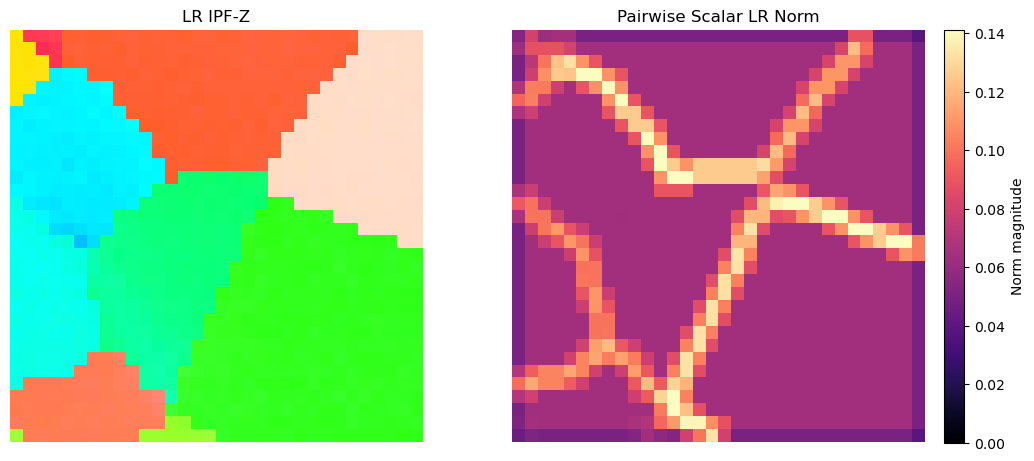

In [34]:
# Side-by-side view: LR IPF and pairwise scalar LR norm
if 'pairwise_scalar_lr' not in globals():
    with torch.no_grad():
        pairwise_scalar_lr = _pairwise_irrep_neighbor_scalars(
            feat_lr=feat_lr_flat,
            lr_shape=(h_lr, w_lr),
            irreps_feat=model.irreps_a1,
            radius=1,
            include_dot=True,
            include_diff=True,
        )

pairwise_plot = pairwise_scalar_lr
if pairwise_plot.dim() == 4:
    pairwise_plot = pairwise_plot.squeeze(0)

pairwise_norm = torch.linalg.norm(pairwise_plot, dim=0).detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5), constrained_layout=True)

axes[0].imshow(lr_rgb)
axes[0].set_title(f'LR IPF-{IPF_REF_DIR}')
axes[0].axis('off')

vmax = float(np.percentile(pairwise_norm, 99.0))
vmax = max(vmax, 1e-8)
im = axes[1].imshow(pairwise_norm, cmap='magma', vmin=0.0, vmax=vmax)
axes[1].set_title('Pairwise Scalar LR Norm')
axes[1].axis('off')

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label('Norm magnitude')

plt.show()


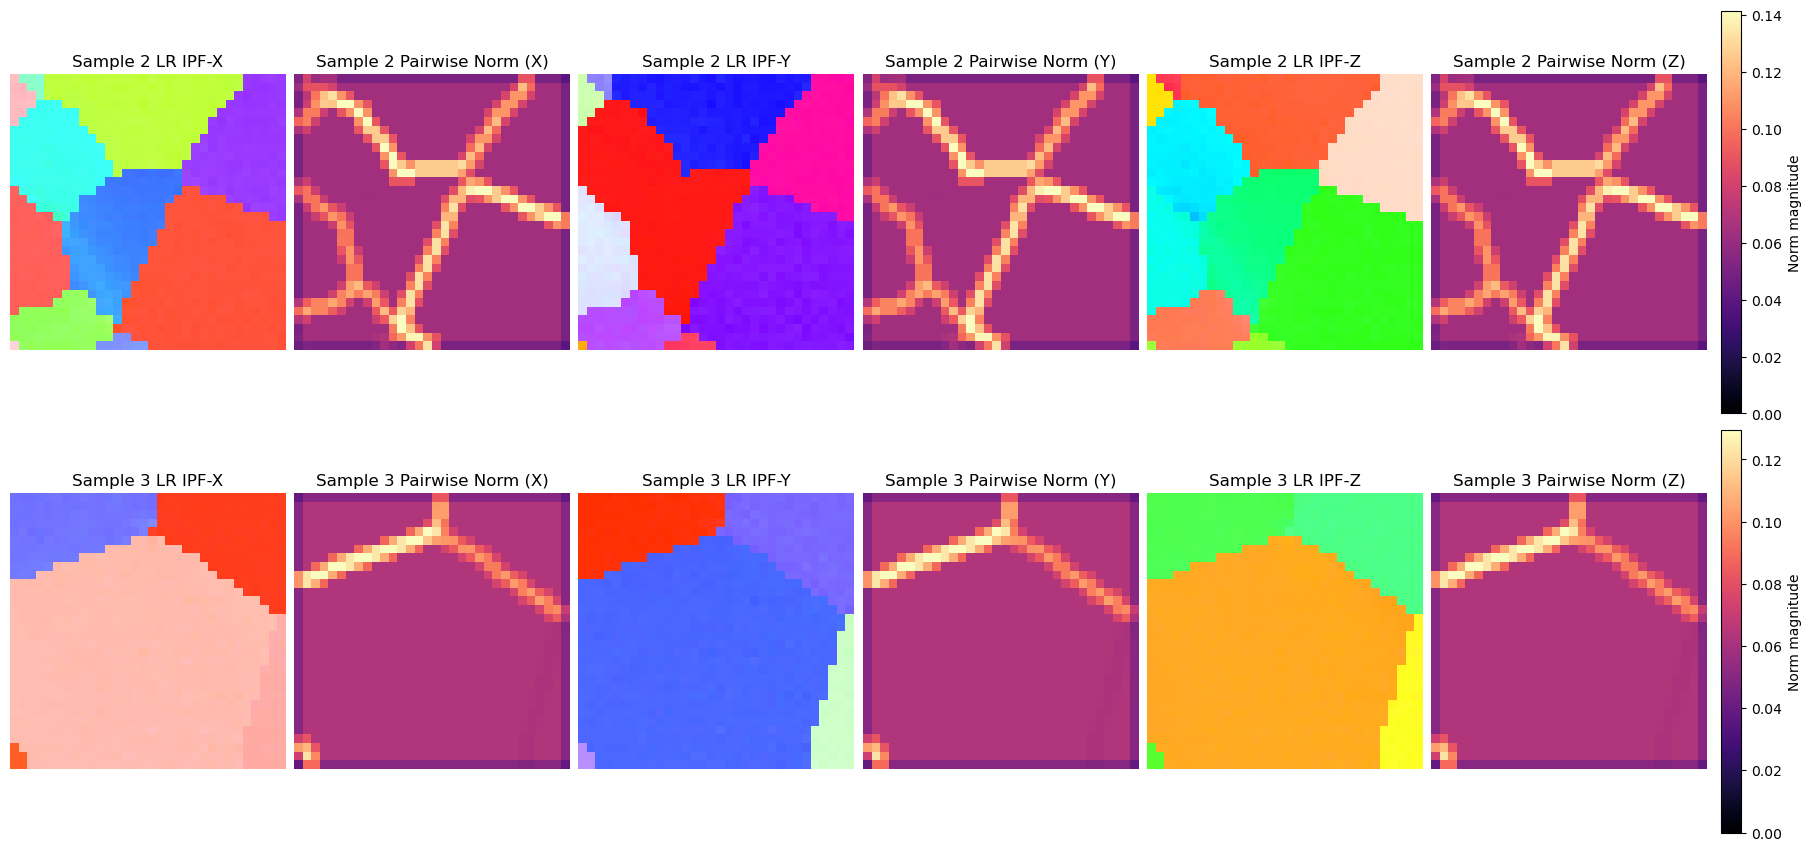

Plotted sample indices: [2, 3]


In [35]:
# Plot LR IPF (X/Y/Z) and pairwise scalar LR norm for two samples
from e3nn.o3 import Irreps

if '_pairwise_irrep_neighbor_scalars' not in globals():
    def _pairwise_irrep_neighbor_scalars(
        feat_lr: torch.Tensor,
        lr_shape: tuple[int, int],
        irreps_feat: Irreps | str,
        radius: int = 1,
        include_dot: bool = True,
        include_diff: bool = True,
    ) -> torch.Tensor:
        irreps_feat = Irreps(irreps_feat)
        H, W = lr_shape

        batched = feat_lr.dim() == 3
        if not batched:
            feat_lr = feat_lr.unsqueeze(0)

        B, N, C = feat_lr.shape
        if N != H * W:
            raise ValueError(f'Expected N={H * W}, got {N}')
        if C != irreps_feat.dim:
            raise ValueError(f'Expected feature dim {irreps_feat.dim}, got {C}')

        feat_img = feat_lr.reshape(B, H, W, C)
        offsets = []
        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                if dy == 0 and dx == 0:
                    continue
                offsets.append((dy, dx))

        chans = []
        for dy, dx in offsets:
            neigh = torch.roll(feat_img, shifts=(dy, dx), dims=(1, 2))

            valid = torch.ones((H, W), device=feat_img.device, dtype=feat_img.dtype)
            if dy > 0:
                valid[:dy, :] = 0.0
            elif dy < 0:
                valid[dy:, :] = 0.0
            if dx > 0:
                valid[:, :dx] = 0.0
            elif dx < 0:
                valid[:, dx:] = 0.0
            valid = valid.reshape(1, H, W, 1)

            for sl, mul_ir in zip(irreps_feat.slices(), irreps_feat):
                mul = int(mul_ir.mul)
                d = int(mul_ir.ir.dim)
                fc = feat_img[..., sl].reshape(B, H, W, mul, d)
                fn = neigh[..., sl].reshape(B, H, W, mul, d)

                if include_dot:
                    dot = (fc * fn).mean(dim=-1) * valid
                    chans.append(dot.permute(0, 3, 1, 2).contiguous())

                if include_diff:
                    diff = ((fc - fn) ** 2).mean(dim=-1) * valid
                    chans.append(diff.permute(0, 3, 1, 2).contiguous())

        if len(chans) == 0:
            raise ValueError('No scalar channels were constructed.')

        out = torch.cat(chans, dim=1)
        return out if batched else out.squeeze(0)

# Optional override: define SAMPLE_INDICES_2 = [i0, i1] in a prior cell
n_ds = len(ds)
requested = list(globals().get('SAMPLE_INDICES_2', [int(SAMPLE_INDEX), int(SAMPLE_INDEX) + 1]))
sample_indices = []
for idx in requested + list(range(n_ds)):
    idx_i = int(idx)
    if 0 <= idx_i < n_ds and idx_i not in sample_indices:
        sample_indices.append(idx_i)
    if len(sample_indices) == 2:
        break

if len(sample_indices) < 2:
    raise RuntimeError(f'Need at least 2 samples in dataset split {SPLIT}, found {n_ds}')

dirs = ['X', 'Y', 'Z']
rows = []

with torch.no_grad():
    for sidx in sample_indices:
        lr_raw_i, _ = ds[sidx]
        lr_hwc_i = normalize_quat(to_hwc_quat(lr_raw_i).to(device=device, dtype=torch.float32))

        h_i, w_i = int(lr_hwc_i.shape[0]), int(lr_hwc_i.shape[1])
        lr_flat_i = lr_hwc_i.reshape(h_i * w_i, 4)
        feat_lr_i = model.encode_a1(lr_flat_i)

        pairwise_i = _pairwise_irrep_neighbor_scalars(
            feat_lr=feat_lr_i,
            lr_shape=(h_i, w_i),
            irreps_feat=model.irreps_a1,
            radius=1,
            include_dot=True,
            include_diff=True,
        )
        pairwise_norm_i = torch.linalg.norm(pairwise_i, dim=0).detach().cpu().numpy()

        lr_np_i = lr_hwc_i.detach().cpu().numpy().astype(np.float32)
        ipf_by_dir = {d: render_ipf_rgb(lr_np_i, sym_class, ref_dir=d) for d in dirs}

        rows.append({
            'sample_idx': sidx,
            'pairwise_norm': pairwise_norm_i,
            'ipf_by_dir': ipf_by_dir,
        })

nrows = len(rows)
fig, axes = plt.subplots(nrows, 6, figsize=(18, 4.2 * nrows), constrained_layout=True)
if nrows == 1:
    axes = np.expand_dims(axes, axis=0)

for r, row in enumerate(rows):
    sidx = row['sample_idx']
    pnorm = row['pairwise_norm']
    vmax = float(np.percentile(pnorm, 99.0))
    vmax = max(vmax, 1e-8)

    norm_axes = []
    im_ref = None
    for j, d in enumerate(dirs):
        ax_ipf = axes[r, 2 * j]
        ax_nrm = axes[r, 2 * j + 1]

        ax_ipf.imshow(row['ipf_by_dir'][d])
        ax_ipf.set_title(f'Sample {sidx} LR IPF-{d}')
        ax_ipf.axis('off')

        im_ref = ax_nrm.imshow(pnorm, cmap='magma', vmin=0.0, vmax=vmax)
        ax_nrm.set_title(f'Sample {sidx} Pairwise Norm ({d})')
        ax_nrm.axis('off')
        norm_axes.append(ax_nrm)

    cbar = fig.colorbar(im_ref, ax=norm_axes, fraction=0.02, pad=0.01)
    cbar.set_label('Norm magnitude')

plt.show()

print(f'Plotted sample indices: {sample_indices}')


In [36]:
import torch
import torch.nn.functional as F
from e3nn.o3 import Irreps


def _shift_with_valid_mask(
    x: torch.Tensor,  # (B,H,W,C)
    dy: int,
    dx: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Shift image features by (dy, dx) using roll, and return a validity mask
    that zeros out wrapped values.
    """
    B, H, W, C = x.shape
    y = torch.roll(x, shifts=(dy, dx), dims=(1, 2))

    valid = torch.ones((H, W), device=x.device, dtype=x.dtype)
    if dy > 0:
        valid[:dy, :] = 0.0
    elif dy < 0:
        valid[dy:, :] = 0.0
    if dx > 0:
        valid[:, :dx] = 0.0
    elif dx < 0:
        valid[:, dx:] = 0.0

    valid = valid.view(1, H, W, 1)  # (1,H,W,1)
    return y, valid


def _pairwise_irrep_neighbor_scalars_allpairs(
    feat_lr: torch.Tensor,
    lr_shape: tuple[int, int],
    irreps_feat: Irreps | str,
    offsets: list[tuple[int, int]] | None = None,
    radius: int = 1,
    include_dot: bool = True,
    include_diff: bool = True,
    include_cosine_mismatch: bool = True,
    eps: float = 1e-8,
) -> torch.Tensor:
    """
    Build directional scalar channels from CENTER-vs-NEIGHBOR pairwise contractions,
    using ALL copy pairs within each irrep block.

    For each offset delta and each irrep block (mul x dim), this returns channels for:
      - dot[a,b]  = <f_center[a], f_neigh[b]> / dim
      - diff[a,b] = ||f_center[a] - f_neigh[b]||^2 / dim
      - cmis[a,b] = 1 - cos(f_center[a], f_neigh[b])

    where a,b run over ALL multiplicity copies in that irrep block.

    Important:
      - channels remain directional because each offset gets its own block of channels
      - no aggregation across offsets
      - no mixing across different irreps
      - all outputs are scalar (0e-type) quantities under the O(3) action

    Args
    ----
    feat_lr:
        (B, H*W, C) or (H*W, C)
    lr_shape:
        (H, W)
    irreps_feat:
        e3nn Irreps matching the last dim of feat_lr
    offsets:
        explicit neighbor offsets. If None, use full stencil from `radius`
        excluding (0,0)
    radius:
        used only when offsets is None
    include_dot / include_diff / include_cosine_mismatch:
        which scalar families to include
    eps:
        numerical stabilizer

    Returns
    -------
    scalar_img:
        (B, S, H, W) or (S, H, W) if unbatched
    """
    irreps_feat = Irreps(irreps_feat)
    H, W = lr_shape

    batched = feat_lr.dim() == 3
    if not batched:
        feat_lr = feat_lr.unsqueeze(0)

    B, N, C = feat_lr.shape
    if N != H * W:
        raise ValueError(f"Expected N={H * W}, got {N}")
    if C != irreps_feat.dim:
        raise ValueError(f"Expected feature dim {irreps_feat.dim}, got {C}")

    if offsets is None:
        offsets = []
        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                if dy == 0 and dx == 0:
                    continue
                offsets.append((dy, dx))

    feat_img = feat_lr.view(B, H, W, C)
    center = feat_img
    chans: list[torch.Tensor] = []

    for dy, dx in offsets:
        neigh, valid = _shift_with_valid_mask(center, dy=dy, dx=dx)
        valid5 = valid.unsqueeze(-1)

        # keep each offset's channels separate
        offset_chans: list[torch.Tensor] = []

        for sl, mul_ir in zip(irreps_feat.slices(), irreps_feat):
            mul = int(mul_ir.mul)
            d = int(mul_ir.ir.dim)

            fc = center[..., sl].view(B, H, W, mul, d)  # (B,H,W,mul,d)
            fn = neigh[..., sl].view(B, H, W, mul, d)   # (B,H,W,mul,d)

            # all copy-pair dot products:
            # gram[..., a, b] = <fc[a], fn[b]> / d
            gram = torch.einsum("bhwmd,bhwnd->bhwmn", fc, fn) / float(d)  # (B,H,W,mul,mul)

            # norms for cosine-like mismatch
            if include_diff or include_cosine_mismatch:
                nfc = (fc * fc).sum(dim=-1) / float(d)  # (B,H,W,mul)
                nfn = (fn * fn).sum(dim=-1) / float(d)  # (B,H,W,mul)

            if include_dot:
                dot = gram * valid5
                dot = dot.permute(0, 3, 4, 1, 2).reshape(B, mul * mul, H, W)
                offset_chans.append(dot)

            if include_diff:
                # ||a-b||^2/d = ||a||^2/d + ||b||^2/d - 2<a,b>/d
                diff = (
                    nfc.unsqueeze(-1) + nfn.unsqueeze(-2) - 2.0 * gram
                ) * valid5
                diff = diff.permute(0, 3, 4, 1, 2).reshape(B, mul * mul, H, W)
                offset_chans.append(diff)

            if include_cosine_mismatch:
                denom = torch.sqrt(
                    nfc.unsqueeze(-1).clamp_min(eps) * nfn.unsqueeze(-2).clamp_min(eps)
                )
                cos = gram / denom
                cmis = (1.0 - cos) * valid5
                cmis = cmis.permute(0, 3, 4, 1, 2).reshape(B, mul * mul, H, W)
                offset_chans.append(cmis)

        if len(offset_chans) == 0:
            raise ValueError("No channels selected.")
        chans.append(torch.cat(offset_chans, dim=1))

    scalar_img = torch.cat(chans, dim=1)  # (B,S,H,W)

    if not batched:
        scalar_img = scalar_img.squeeze(0)

    return scalar_img

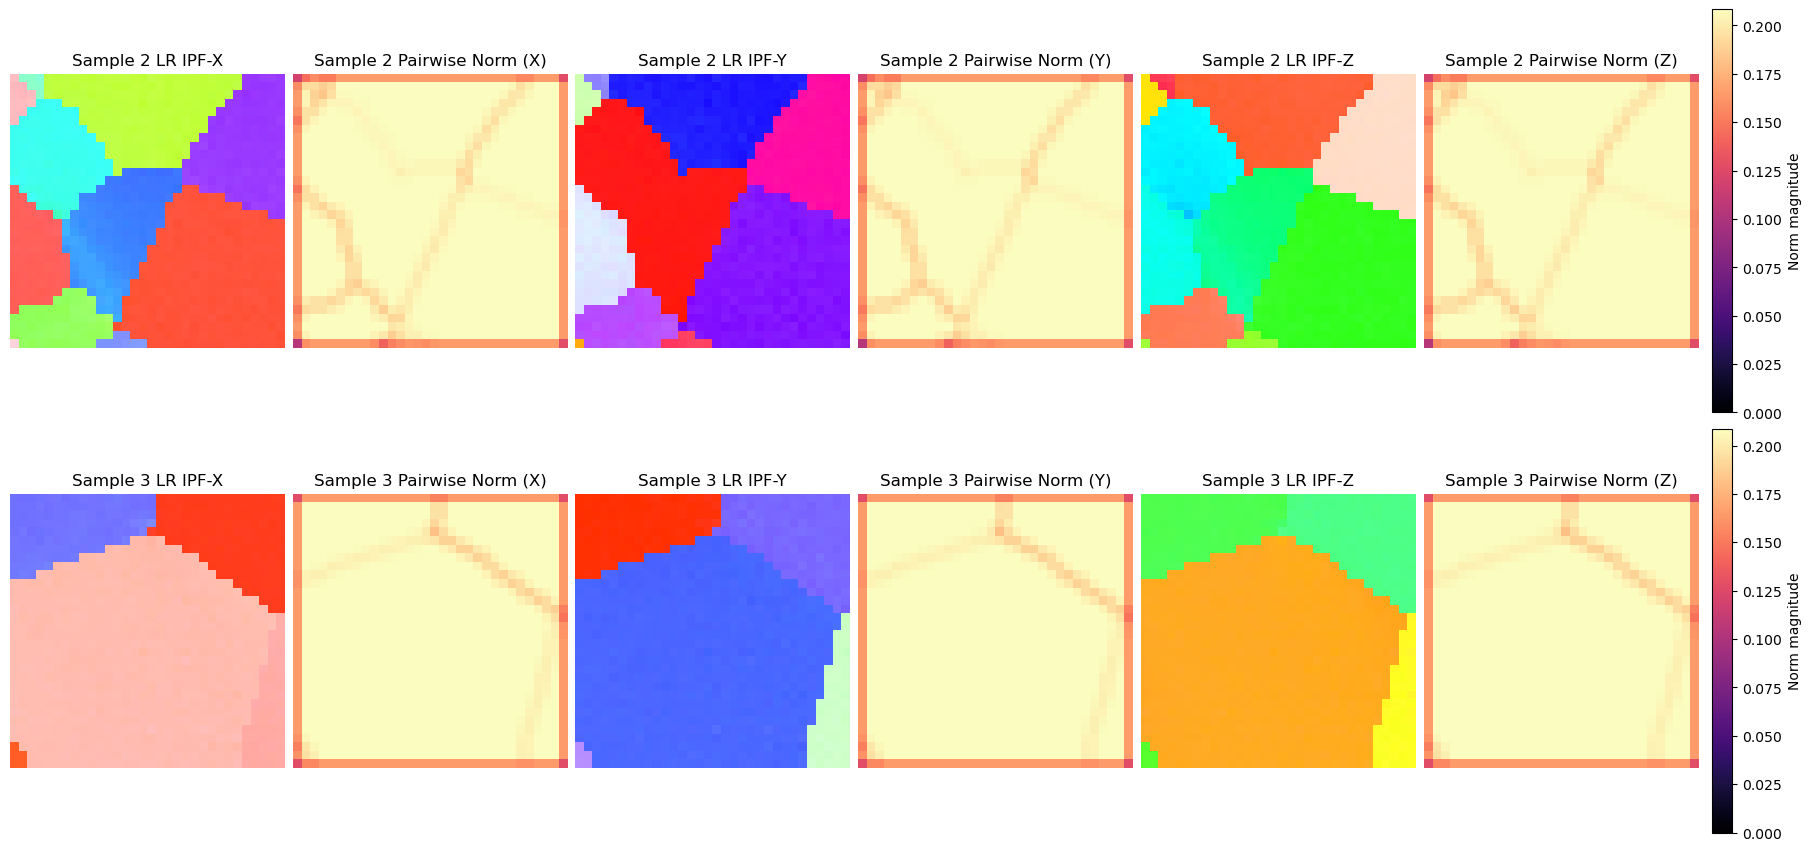

Plotted sample indices: [2, 3]


In [37]:
# Plot LR IPF (X/Y/Z) and pairwise scalar LR norm for two samples
from e3nn.o3 import Irreps

# Optional override: define SAMPLE_INDICES_2 = [i0, i1] in a prior cell
n_ds = len(ds)
requested = list(globals().get('SAMPLE_INDICES_2', [int(SAMPLE_INDEX), int(SAMPLE_INDEX) + 1]))
sample_indices = []
for idx in requested + list(range(n_ds)):
    idx_i = int(idx)
    if 0 <= idx_i < n_ds and idx_i not in sample_indices:
        sample_indices.append(idx_i)
    if len(sample_indices) == 2:
        break

if len(sample_indices) < 2:
    raise RuntimeError(f'Need at least 2 samples in dataset split {SPLIT}, found {n_ds}')

dirs = ['X', 'Y', 'Z']
rows = []

with torch.no_grad():
    for sidx in sample_indices:
        lr_raw_i, _ = ds[sidx]
        lr_hwc_i = normalize_quat(to_hwc_quat(lr_raw_i).to(device=device, dtype=torch.float32))

        h_i, w_i = int(lr_hwc_i.shape[0]), int(lr_hwc_i.shape[1])
        lr_flat_i = lr_hwc_i.reshape(h_i * w_i, 4)
        feat_lr_i = model.encode_a1(lr_flat_i)

        pairwise_i = _pairwise_irrep_neighbor_scalars_allpairs(
            feat_lr=feat_lr_i,
            lr_shape=(h_i, w_i),
            irreps_feat=model.irreps_a1,
            radius=1,
            include_dot=True,
            include_diff=True,
            include_cosine_mismatch=False,

        )
        pairwise_norm_i = torch.linalg.norm(pairwise_i, dim=0).detach().cpu().numpy()

        lr_np_i = lr_hwc_i.detach().cpu().numpy().astype(np.float32)
        ipf_by_dir = {d: render_ipf_rgb(lr_np_i, sym_class, ref_dir=d) for d in dirs}

        rows.append({
            'sample_idx': sidx,
            'pairwise_norm': pairwise_norm_i,
            'ipf_by_dir': ipf_by_dir,
        })

nrows = len(rows)
fig, axes = plt.subplots(nrows, 6, figsize=(18, 4.2 * nrows), constrained_layout=True)
if nrows == 1:
    axes = np.expand_dims(axes, axis=0)

for r, row in enumerate(rows):
    sidx = row['sample_idx']
    pnorm = row['pairwise_norm']
    vmax = float(np.percentile(pnorm, 99.0))
    vmax = max(vmax, 1e-8)

    norm_axes = []
    im_ref = None
    for j, d in enumerate(dirs):
        ax_ipf = axes[r, 2 * j]
        ax_nrm = axes[r, 2 * j + 1]

        ax_ipf.imshow(row['ipf_by_dir'][d])
        ax_ipf.set_title(f'Sample {sidx} LR IPF-{d}')
        ax_ipf.axis('off')

        im_ref = ax_nrm.imshow(pnorm, cmap='magma', vmin=0.0, vmax=vmax)
        ax_nrm.set_title(f'Sample {sidx} Pairwise Norm ({d})')
        ax_nrm.axis('off')
        norm_axes.append(ax_nrm)

    cbar = fig.colorbar(im_ref, ax=norm_axes, fraction=0.02, pad=0.01)
    cbar.set_label('Norm magnitude')

plt.show()

print(f'Plotted sample indices: {sample_indices}')


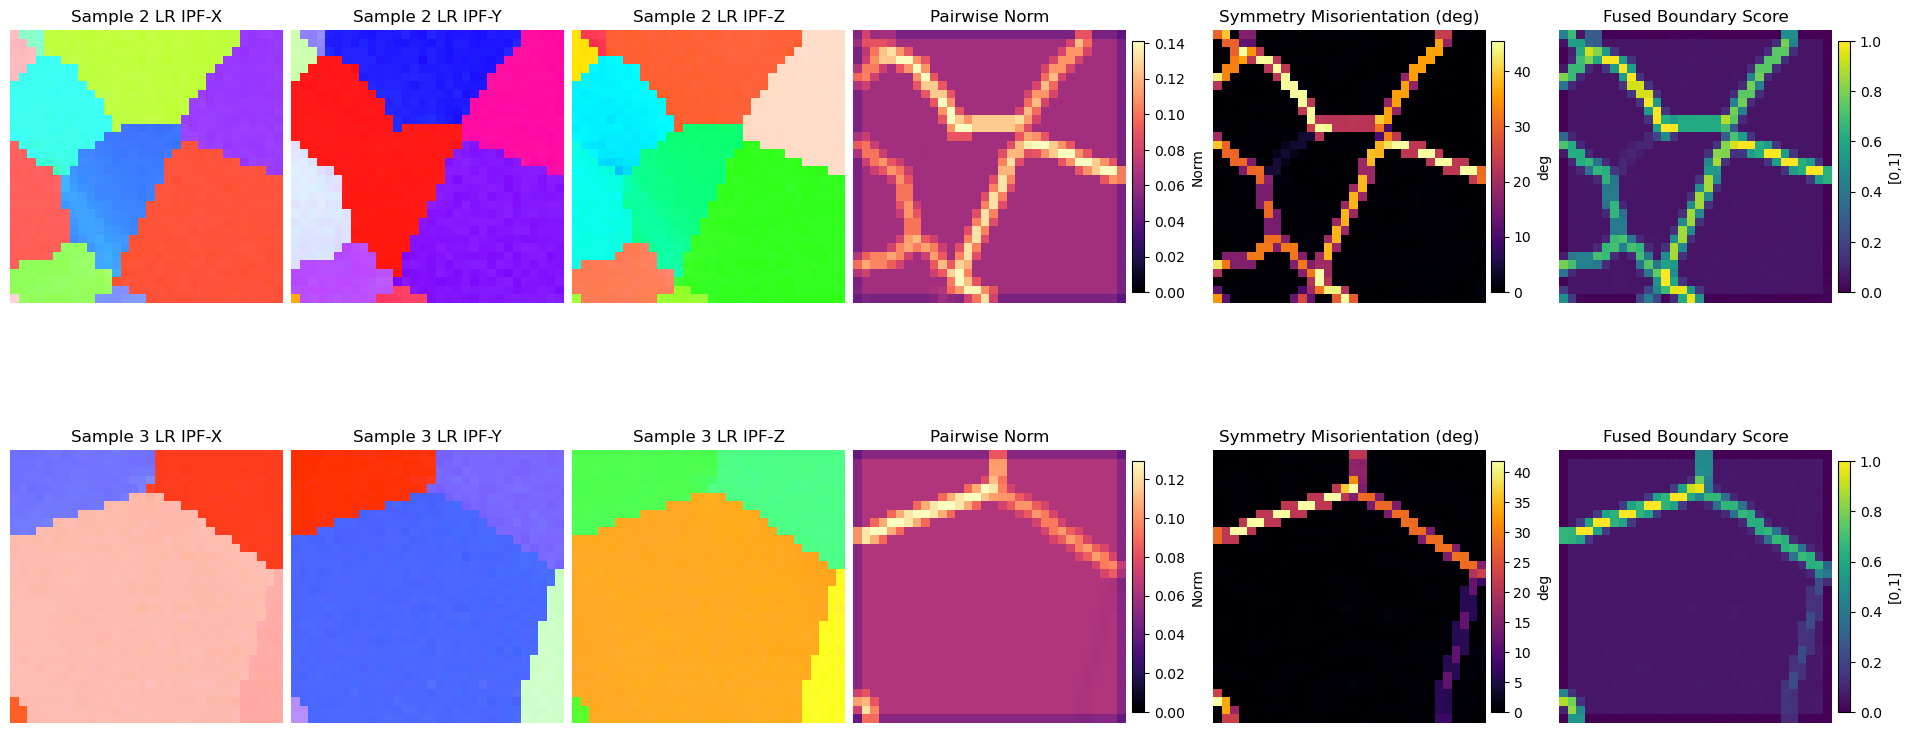

Tip: for boundary masks, threshold misorientation around 2-5 deg depending on desired sensitivity.


In [38]:
# Stronger boundary diagnostic: symmetry-aware misorientation vs pairwise norm
def _left_mult_matrix_wxyz_batch(q_syms: torch.Tensor) -> torch.Tensor:
    """q_syms: (G,4) -> (G,4,4) left-multiplication matrices."""
    w, x, y, z = q_syms.unbind(dim=-1)
    row0 = torch.stack([w, -x, -y, -z], dim=-1)
    row1 = torch.stack([x,  w, -z,  y], dim=-1)
    row2 = torch.stack([y,  z,  w, -x], dim=-1)
    row3 = torch.stack([z, -y,  x,  w], dim=-1)
    return torch.stack([row0, row1, row2, row3], dim=1)

def _misorientation_angle_sym(q1: torch.Tensor, q2: torch.Tensor, sym_ops_4x4: torch.Tensor) -> torch.Tensor:
    """Symmetry-aware misorientation angle in radians for (...,4) pairs."""
    q2var = torch.einsum('gij,...j->...gi', sym_ops_4x4, q2)
    dots = (q1.unsqueeze(-2) * q2var).sum(dim=-1).abs().clamp(0.0, 1.0)
    best = dots.max(dim=-1).values
    return 2.0 * torch.acos(best)

def _neighbor_misorientation_map_deg(q_hwc: torch.Tensor, sym_ops_4x4: torch.Tensor) -> torch.Tensor:
    """q_hwc: (H,W,4) -> (H,W) average 4-neighbor misorientation (deg)."""
    H, W = int(q_hwc.shape[0]), int(q_hwc.shape[1])

    qL = q_hwc[:, :-1, :]
    qR = q_hwc[:, 1:, :]
    mis_x = _misorientation_angle_sym(qL, qR, sym_ops_4x4)

    qU = q_hwc[:-1, :, :]
    qD = q_hwc[1:, :, :]
    mis_y = _misorientation_angle_sym(qU, qD, sym_ops_4x4)

    acc = torch.zeros((H, W), device=q_hwc.device, dtype=q_hwc.dtype)
    cnt = torch.zeros((H, W), device=q_hwc.device, dtype=q_hwc.dtype)

    acc[:, :-1] += mis_x
    acc[:, 1:] += mis_x
    cnt[:, :-1] += 1.0
    cnt[:, 1:] += 1.0

    acc[:-1, :] += mis_y
    acc[1:, :] += mis_y
    cnt[:-1, :] += 1.0
    cnt[1:, :] += 1.0

    mis_avg = acc / cnt.clamp_min(1.0)
    return mis_avg * (180.0 / np.pi)

def _normalize01(x: np.ndarray, p_lo: float = 1.0, p_hi: float = 99.0, eps: float = 1e-8) -> np.ndarray:
    lo = float(np.percentile(x, p_lo))
    hi = float(np.percentile(x, p_hi))
    if hi - lo < eps:
        return np.zeros_like(x, dtype=np.float32)
    y = (x - lo) / (hi - lo)
    return np.clip(y, 0.0, 1.0).astype(np.float32)

sym_quats = model.encoder.sym_ops.to(device=device, dtype=torch.float32)
sym_ops_4x4 = _left_mult_matrix_wxyz_batch(sym_quats)

# Reuse sample indices from previous cell if present; else fallback
if 'sample_indices' not in globals() or len(sample_indices) < 2:
    n_ds = len(ds)
    sample_indices = [int(SAMPLE_INDEX)]
    for k in range(n_ds):
        if k not in sample_indices:
            sample_indices.append(k)
        if len(sample_indices) == 2:
            break

rows = []
with torch.no_grad():
    for sidx in sample_indices[:2]:
        lr_raw_i, _ = ds[int(sidx)]
        lr_hwc_i = normalize_quat(to_hwc_quat(lr_raw_i).to(device=device, dtype=torch.float32))

        H_i, W_i = int(lr_hwc_i.shape[0]), int(lr_hwc_i.shape[1])
        lr_flat_i = lr_hwc_i.reshape(H_i * W_i, 4)
        feat_lr_i = model.encode_a1(lr_flat_i)
        pairwise_i = _pairwise_irrep_neighbor_scalars(
            feat_lr=feat_lr_i,
            lr_shape=(H_i, W_i),
            irreps_feat=model.irreps_a1,
            radius=1,
            include_dot=True,
            include_diff=True,
        )
        pairwise_norm_i = torch.linalg.norm(pairwise_i, dim=0).detach().cpu().numpy()

        mis_deg_i = _neighbor_misorientation_map_deg(lr_hwc_i, sym_ops_4x4).detach().cpu().numpy()

        # Simple fusion that tends to recover weak boundaries better.
        fused_i = 0.35 * _normalize01(pairwise_norm_i) + 0.65 * _normalize01(mis_deg_i)

        lr_np_i = lr_hwc_i.detach().cpu().numpy().astype(np.float32)
        ipf_x = render_ipf_rgb(lr_np_i, sym_class, ref_dir='X')
        ipf_y = render_ipf_rgb(lr_np_i, sym_class, ref_dir='Y')
        ipf_z = render_ipf_rgb(lr_np_i, sym_class, ref_dir='Z')

        rows.append({
            'sample_idx': int(sidx),
            'ipf_x': ipf_x,
            'ipf_y': ipf_y,
            'ipf_z': ipf_z,
            'pairwise_norm': pairwise_norm_i,
            'mis_deg': mis_deg_i,
            'fused': fused_i,
        })

fig, axes = plt.subplots(len(rows), 6, figsize=(19, 4.2 * len(rows)), constrained_layout=True)
if len(rows) == 1:
    axes = np.expand_dims(axes, axis=0)

for r, row in enumerate(rows):
    sidx = row['sample_idx']
    axes[r, 0].imshow(row['ipf_x']); axes[r, 0].set_title(f'Sample {sidx} LR IPF-X'); axes[r, 0].axis('off')
    axes[r, 1].imshow(row['ipf_y']); axes[r, 1].set_title(f'Sample {sidx} LR IPF-Y'); axes[r, 1].axis('off')
    axes[r, 2].imshow(row['ipf_z']); axes[r, 2].set_title(f'Sample {sidx} LR IPF-Z'); axes[r, 2].axis('off')

    p = row['pairwise_norm']
    vmax_p = max(float(np.percentile(p, 99.0)), 1e-8)
    im_p = axes[r, 3].imshow(p, cmap='magma', vmin=0.0, vmax=vmax_p)
    axes[r, 3].set_title('Pairwise Norm')
    axes[r, 3].axis('off')
    cb_p = fig.colorbar(im_p, ax=axes[r, 3], fraction=0.046, pad=0.02)
    cb_p.set_label('Norm')

    m = row['mis_deg']
    vmax_m = max(float(np.percentile(m, 99.0)), 1e-6)
    im_m = axes[r, 4].imshow(m, cmap='inferno', vmin=0.0, vmax=vmax_m)
    axes[r, 4].set_title('Symmetry Misorientation (deg)')
    axes[r, 4].axis('off')
    cb_m = fig.colorbar(im_m, ax=axes[r, 4], fraction=0.046, pad=0.02)
    cb_m.set_label('deg')

    im_f = axes[r, 5].imshow(row['fused'], cmap='viridis', vmin=0.0, vmax=1.0)
    axes[r, 5].set_title('Fused Boundary Score')
    axes[r, 5].axis('off')
    cb_f = fig.colorbar(im_f, ax=axes[r, 5], fraction=0.046, pad=0.02)
    cb_f.set_label('[0,1]')

plt.show()
print('Tip: for boundary masks, threshold misorientation around 2-5 deg depending on desired sensitivity.')


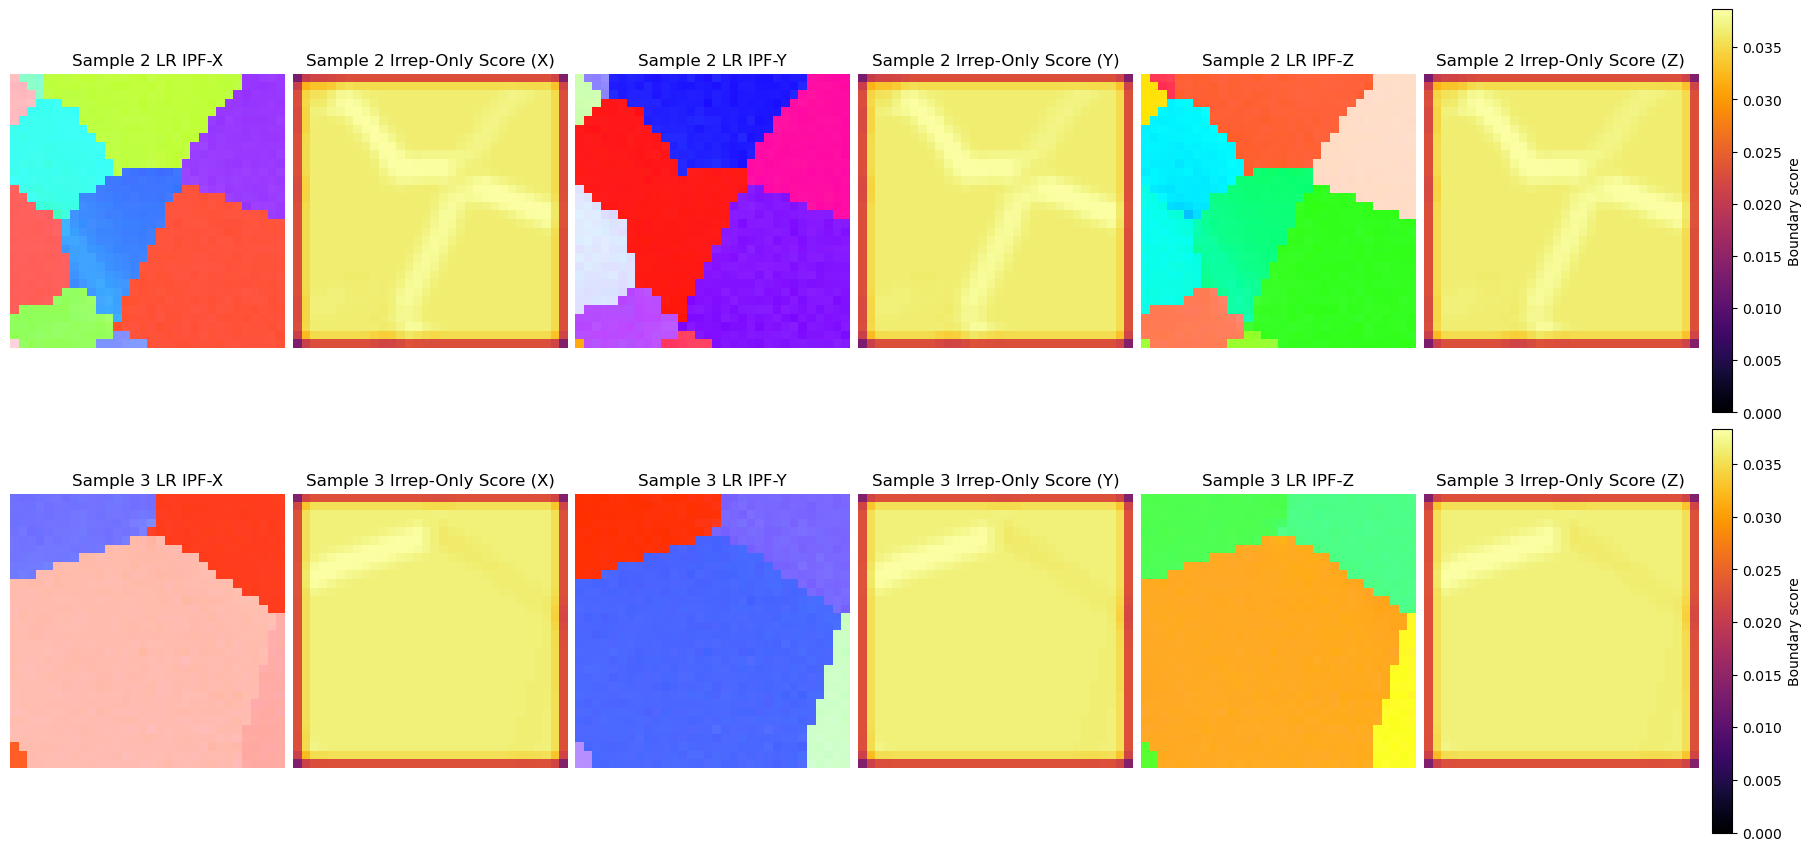

Sample 2: pairwise allpairs tensor shape = (96, 32, 32)
Sample 3: pairwise allpairs tensor shape = (96, 32, 32)


In [39]:
# Irrep-only boundary score (no quaternion misorientation), for 2 samples and IPF X/Y/Z
import torch
import torch.nn.functional as F
from e3nn.o3 import Irreps

def _shift_with_valid_mask(
    x: torch.Tensor,  # (B,H,W,C)
    dy: int,
    dx: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    B, H, W, C = x.shape
    y = torch.roll(x, shifts=(dy, dx), dims=(1, 2))

    valid = torch.ones((H, W), device=x.device, dtype=x.dtype)
    if dy > 0:
        valid[:dy, :] = 0.0
    elif dy < 0:
        valid[dy:, :] = 0.0
    if dx > 0:
        valid[:, :dx] = 0.0
    elif dx < 0:
        valid[:, dx:] = 0.0

    valid = valid.reshape(1, H, W, 1)
    return y, valid


def _pairwise_irrep_neighbor_scalars_allpairs(
    feat_lr: torch.Tensor,
    lr_shape: tuple[int, int],
    irreps_feat: Irreps | str,
    offsets: list[tuple[int, int]] | None = None,
    radius: int = 1,
    include_dot: bool = True,
    include_diff: bool = True,
    include_cosine_mismatch: bool = True,
    eps: float = 1e-8,
) -> torch.Tensor:
    irreps_feat = Irreps(irreps_feat)
    H, W = lr_shape

    batched = feat_lr.dim() == 3
    if not batched:
        feat_lr = feat_lr.unsqueeze(0)

    B, N, C = feat_lr.shape
    if N != H * W:
        raise ValueError(f'Expected N={H * W}, got {N}')
    if C != irreps_feat.dim:
        raise ValueError(f'Expected feature dim {irreps_feat.dim}, got {C}')

    if offsets is None:
        offsets = []
        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                if dy == 0 and dx == 0:
                    continue
                offsets.append((dy, dx))

    feat_img = feat_lr.reshape(B, H, W, C)
    center = feat_img
    chans: list[torch.Tensor] = []

    for dy, dx in offsets:
        neigh, valid = _shift_with_valid_mask(center, dy=dy, dx=dx)
        valid5 = valid.unsqueeze(-1)

        offset_chans: list[torch.Tensor] = []
        for sl, mul_ir in zip(irreps_feat.slices(), irreps_feat):
            mul = int(mul_ir.mul)
            d = int(mul_ir.ir.dim)

            fc = center[..., sl].reshape(B, H, W, mul, d)
            fn = neigh[..., sl].reshape(B, H, W, mul, d)

            gram = torch.einsum('bhwmd,bhwnd->bhwmn', fc, fn) / float(d)

            if include_diff or include_cosine_mismatch:
                nfc = (fc * fc).sum(dim=-1) / float(d)
                nfn = (fn * fn).sum(dim=-1) / float(d)

            if include_dot:
                dot = (gram * valid5).permute(0, 3, 4, 1, 2).reshape(B, mul * mul, H, W)
                offset_chans.append(dot)

            if include_diff:
                diff = (nfc.unsqueeze(-1) + nfn.unsqueeze(-2) - 2.0 * gram) * valid5
                diff = diff.permute(0, 3, 4, 1, 2).reshape(B, mul * mul, H, W)
                offset_chans.append(diff)

            if include_cosine_mismatch:
                denom = torch.sqrt(nfc.unsqueeze(-1).clamp_min(eps) * nfn.unsqueeze(-2).clamp_min(eps))
                cos = gram / denom
                cmis = ((1.0 - cos) * valid5).permute(0, 3, 4, 1, 2).reshape(B, mul * mul, H, W)
                offset_chans.append(cmis)

        if len(offset_chans) == 0:
            raise ValueError('No channels selected.')
        chans.append(torch.cat(offset_chans, dim=1))

    scalar_img = torch.cat(chans, dim=1)
    return scalar_img if batched else scalar_img.squeeze(0)


def _irrep_only_boundary_score(
    feat_lr_flat: torch.Tensor,
    lr_shape: tuple[int, int],
    irreps_feat: Irreps | str,
) -> tuple[torch.Tensor, torch.Tensor]:
    pair_all = _pairwise_irrep_neighbor_scalars_allpairs(
        feat_lr=feat_lr_flat,
        lr_shape=lr_shape,
        irreps_feat=irreps_feat,
        radius=1,
        include_dot=True,
        include_diff=True,
        include_cosine_mismatch=False,
    )

    if pair_all.dim() == 4:
        pair_all = pair_all.squeeze(0)  # (S,H,W)

    S = int(pair_all.shape[0])
    k = max(1, int(round(0.12 * S)))
    topk_mean = torch.topk(pair_all, k=k, dim=0).values.mean(dim=0)
    mean_all = pair_all.mean(dim=0)

    score = 0.70 * topk_mean + 0.30 * mean_all
    score = F.avg_pool2d(score.unsqueeze(0).unsqueeze(0), kernel_size=3, stride=1, padding=1).squeeze(0).squeeze(0)
    return pair_all, score


# Optional override: SAMPLE_INDICES_2 = [i0, i1]
n_ds = len(ds)
requested = list(globals().get('SAMPLE_INDICES_2', [int(SAMPLE_INDEX), int(SAMPLE_INDEX) + 1]))
sample_indices_irrep = []
for idx in requested + list(range(n_ds)):
    idx_i = int(idx)
    if 0 <= idx_i < n_ds and idx_i not in sample_indices_irrep:
        sample_indices_irrep.append(idx_i)
    if len(sample_indices_irrep) == 2:
        break

if len(sample_indices_irrep) < 2:
    raise RuntimeError(f'Need at least 2 samples in dataset split {SPLIT}, found {n_ds}')

dirs = ['X', 'Y', 'Z']
rows = []
with torch.no_grad():
    for sidx in sample_indices_irrep:
        lr_raw_i, _ = ds[sidx]
        lr_hwc_i = normalize_quat(to_hwc_quat(lr_raw_i).to(device=device, dtype=torch.float32))

        h_i, w_i = int(lr_hwc_i.shape[0]), int(lr_hwc_i.shape[1])
        lr_flat_i = lr_hwc_i.reshape(h_i * w_i, 4)
        feat_lr_i = model.encode_a1(lr_flat_i)

        pair_all_i, score_i = _irrep_only_boundary_score(
            feat_lr_flat=feat_lr_i,
            lr_shape=(h_i, w_i),
            irreps_feat=model.irreps_a1,
        )

        score_np = score_i.detach().cpu().numpy()
        lr_np_i = lr_hwc_i.detach().cpu().numpy().astype(np.float32)
        ipf_by_dir = {d: render_ipf_rgb(lr_np_i, sym_class, ref_dir=d) for d in dirs}

        rows.append({
            'sample_idx': sidx,
            'ipf_by_dir': ipf_by_dir,
            'score': score_np,
            'pair_shape': tuple(pair_all_i.shape),
        })

fig, axes = plt.subplots(len(rows), 6, figsize=(18, 4.2 * len(rows)), constrained_layout=True)
if len(rows) == 1:
    axes = np.expand_dims(axes, axis=0)

for r, row in enumerate(rows):
    sidx = row['sample_idx']
    score = row['score']
    vmax = max(float(np.percentile(score, 99.0)), 1e-8)

    for j, d in enumerate(dirs):
        ax_ipf = axes[r, 2 * j]
        ax_s = axes[r, 2 * j + 1]

        ax_ipf.imshow(row['ipf_by_dir'][d])
        ax_ipf.set_title(f'Sample {sidx} LR IPF-{d}')
        ax_ipf.axis('off')

        im = ax_s.imshow(score, cmap='inferno', vmin=0.0, vmax=vmax)
        ax_s.set_title(f'Sample {sidx} Irrep-Only Score ({d})')
        ax_s.axis('off')

    cbar = fig.colorbar(im, ax=[axes[r, 1], axes[r, 3], axes[r, 5]], fraction=0.02, pad=0.01)
    cbar.set_label('Boundary score')

plt.show()

for row in rows:
    print(f"Sample {row['sample_idx']}: pairwise allpairs tensor shape = {row['pair_shape']}")


In [40]:
import torch
import torch.nn.functional as F
from e3nn.o3 import Irreps

def _shift_with_valid_mask_v2(x: torch.Tensor, dy: int, dx: int) -> tuple[torch.Tensor, torch.Tensor]:
    """Roll by (dy, dx) and return validity mask to suppress wraparound."""
    B, H, W, C = x.shape
    y = torch.roll(x, shifts=(dy, dx), dims=(1, 2))

    valid = torch.ones((H, W), device=x.device, dtype=x.dtype)
    if dy > 0:
        valid[:dy, :] = 0.0
    elif dy < 0:
        valid[dy:, :] = 0.0
    if dx > 0:
        valid[:, :dx] = 0.0
    elif dx < 0:
        valid[:, dx:] = 0.0

    return y, valid.reshape(1, H, W)

def build_irrep_boundary_evidence_v2(
    feat_lr: torch.Tensor,
    lr_shape: tuple[int, int],
    irreps_feat: Irreps | str,
    offsets: list[tuple[int, int]] | None = None,
    radius: int = 1,
    eps: float = 1e-8,
) -> dict[str, object]:
    """
    Build irreps-only boundary evidence maps from center-vs-neighbor comparisons.

    Outputs include:
      - E_{L,delta}: mean squared mismatch over full irrep block (all copies+m)
      - C_{L,delta}: cosine mismatch over full irrep block

    Returns dict with maps, stacked tensor, channel names, offsets.
    """
    irreps_feat = Irreps(irreps_feat)
    H, W = lr_shape

    batched = feat_lr.dim() == 3
    if not batched:
        feat_lr = feat_lr.unsqueeze(0)

    B, N, C = feat_lr.shape
    if N != H * W:
        raise ValueError(f"Expected N={H * W}, got {N}")
    if C != irreps_feat.dim:
        raise ValueError(f"Expected feature dim {irreps_feat.dim}, got {C}")

    if offsets is None:
        offsets = []
        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                if dy == 0 and dx == 0:
                    continue
                offsets.append((dy, dx))

    feat_img = feat_lr.reshape(B, H, W, C)
    maps: dict[str, torch.Tensor] = {}
    stacked: list[torch.Tensor] = []
    channel_names: list[str] = []

    block_labels = []
    seen = {}
    for mul_ir in irreps_feat:
        ir = mul_ir.ir
        label = f"{ir.l}{'e' if ir.p == 1 else 'o'}"
        seen[label] = seen.get(label, 0) + 1
        if seen[label] > 1:
            label = f"{label}_blk{seen[label]}"
        block_labels.append(label)

    for dy, dx in offsets:
        neigh, valid = _shift_with_valid_mask_v2(feat_img, dy=dy, dx=dx)

        for blk_idx, (sl, mul_ir) in enumerate(zip(irreps_feat.slices(), irreps_feat)):
            mul = int(mul_ir.mul)
            d = int(mul_ir.ir.dim)
            label = block_labels[blk_idx]

            fc = feat_img[..., sl].reshape(B, H, W, mul * d)
            fn = neigh[..., sl].reshape(B, H, W, mul * d)

            E = ((fc - fn) ** 2).mean(dim=-1)
            E = E * valid

            dot = (fc * fn).sum(dim=-1)
            nfc = (fc * fc).sum(dim=-1).clamp_min(eps)
            nfn = (fn * fn).sum(dim=-1).clamp_min(eps)
            cos = (dot / torch.sqrt(nfc * nfn)).clamp(-1.0, 1.0)
            Cmis = (1.0 - cos) * valid

            name_E = f"E_{label}_dy{dy:+d}_dx{dx:+d}"
            name_C = f"C_{label}_dy{dy:+d}_dx{dx:+d}"

            maps[name_E] = E if batched else E.squeeze(0)
            maps[name_C] = Cmis if batched else Cmis.squeeze(0)

            stacked.append(E.unsqueeze(1))
            stacked.append(Cmis.unsqueeze(1))
            channel_names.extend([name_E, name_C])

    tensor = torch.cat(stacked, dim=1)
    if not batched:
        tensor = tensor.squeeze(0)

    return {
        'maps': maps,
        'tensor': tensor,
        'channel_names': channel_names,
        'offsets': offsets,
    }


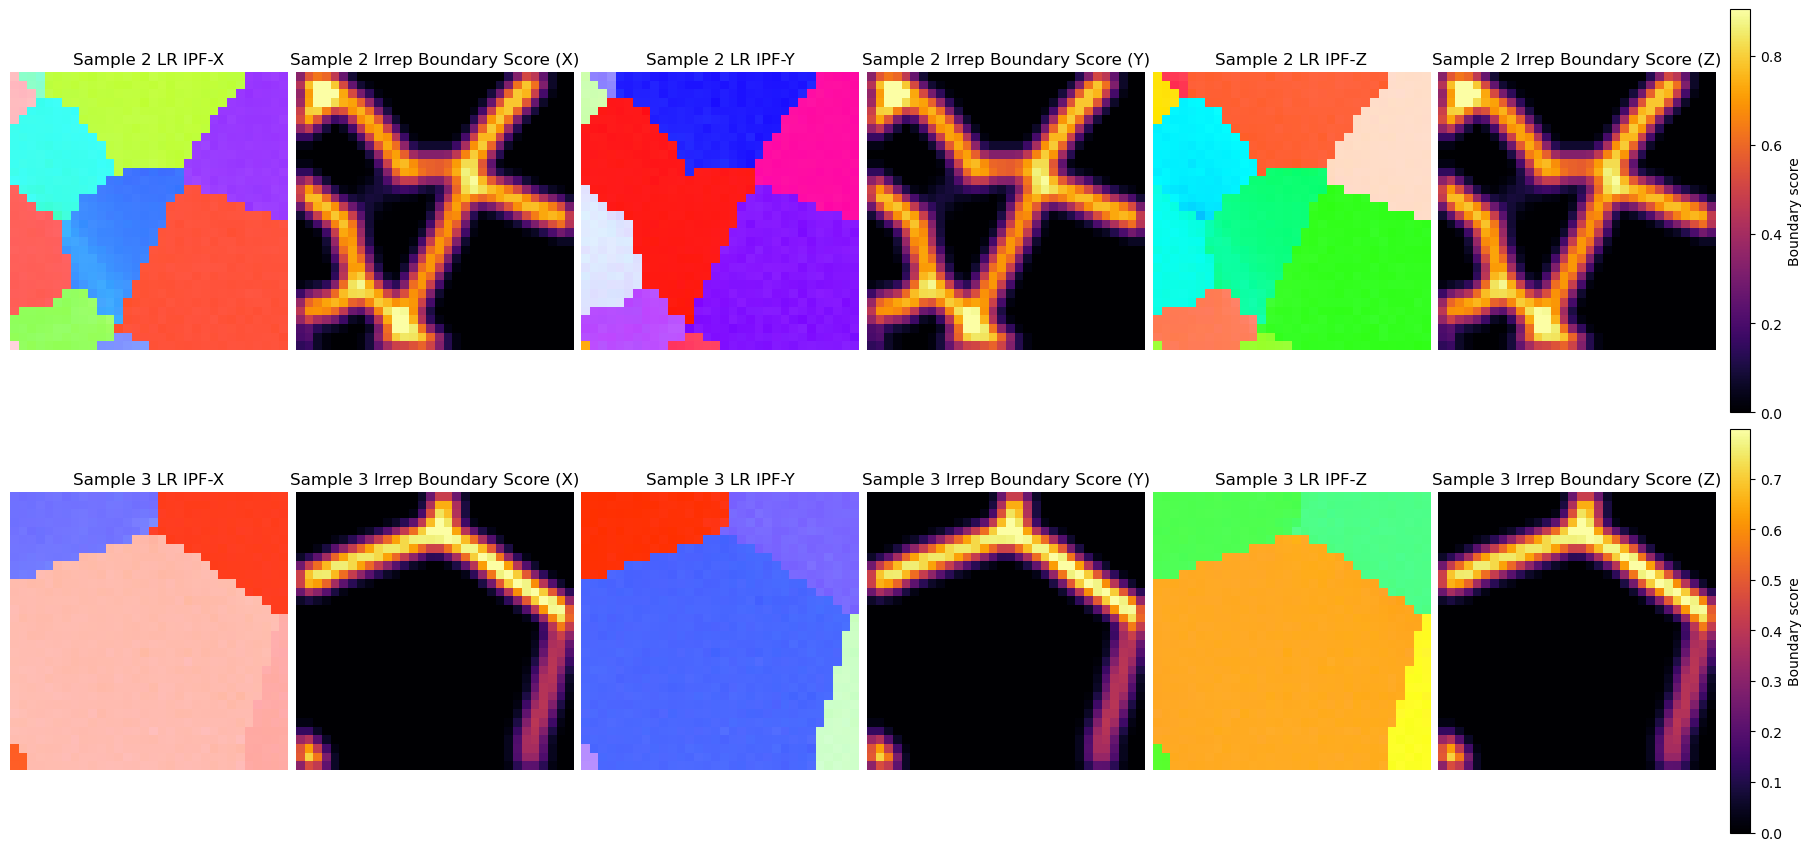

Sample 2: pairwise tensor shape (72, 32, 32)
Sample 3: pairwise tensor shape (72, 32, 32)


In [41]:
# Irreps-only boundary evidence visualization for 2 samples and IPF X/Y/Z
offsets_v2 = [
    (-1, 0), (1, 0), (0, -1), (0, 1),
    (-1, -1), (-1, 1), (1, -1), (1, 1),
    (-2, 0), (2, 0), (0, -2), (0, 2),
]

n_ds = len(ds)
requested = list(globals().get('SAMPLE_INDICES_2', [int(SAMPLE_INDEX), int(SAMPLE_INDEX) + 1]))
sample_indices_v2 = []
for idx in requested + list(range(n_ds)):
    idx_i = int(idx)
    if 0 <= idx_i < n_ds and idx_i not in sample_indices_v2:
        sample_indices_v2.append(idx_i)
    if len(sample_indices_v2) == 2:
        break

dirs = ['X', 'Y', 'Z']
rows = []

with torch.no_grad():
    for sidx in sample_indices_v2:
        lr_raw_i, _ = ds[sidx]
        lr_hwc_i = normalize_quat(to_hwc_quat(lr_raw_i).to(device=device, dtype=torch.float32))
        h_i, w_i = int(lr_hwc_i.shape[0]), int(lr_hwc_i.shape[1])

        lr_flat_i = lr_hwc_i.reshape(h_i * w_i, 4)
        feat_lr_i = model.encode_a1(lr_flat_i)

        evidence = build_irrep_boundary_evidence_v2(
            feat_lr=feat_lr_i,
            lr_shape=(h_i, w_i),
            irreps_feat=model.irreps_a1,
            offsets=offsets_v2,
        )

        pairwise_tensor = evidence['tensor']  # (S,H,W) for unbatched input
        if pairwise_tensor.dim() == 4:
            pairwise_tensor = pairwise_tensor.squeeze(0)

        # Robust irreps-only score from strongest channels + global mean
        S = int(pairwise_tensor.shape[0])
        k = max(1, int(round(0.12 * S)))
        topk_mean = torch.topk(pairwise_tensor, k=k, dim=0).values.mean(dim=0)
        mean_all = pairwise_tensor.mean(dim=0)
        score = 0.70 * topk_mean + 0.30 * mean_all
        score = F.avg_pool2d(score.unsqueeze(0).unsqueeze(0), 3, 1, 1).squeeze(0).squeeze(0)

        score_np = score.detach().cpu().numpy()
        lr_np_i = lr_hwc_i.detach().cpu().numpy().astype(np.float32)
        ipf_by_dir = {d: render_ipf_rgb(lr_np_i, sym_class, ref_dir=d) for d in dirs}

        rows.append({
            'sample_idx': int(sidx),
            'ipf_by_dir': ipf_by_dir,
            'score': score_np,
            'shape_pair': tuple(pairwise_tensor.shape),
        })

fig, axes = plt.subplots(len(rows), 6, figsize=(18, 4.2 * len(rows)), constrained_layout=True)
if len(rows) == 1:
    axes = np.expand_dims(axes, axis=0)

for r, row in enumerate(rows):
    sidx = row['sample_idx']
    score = row['score']
    vmax = max(float(np.percentile(score, 99.0)), 1e-8)

    for j, d in enumerate(dirs):
        ax_ipf = axes[r, 2 * j]
        ax_s = axes[r, 2 * j + 1]

        ax_ipf.imshow(row['ipf_by_dir'][d])
        ax_ipf.set_title(f'Sample {sidx} LR IPF-{d}')
        ax_ipf.axis('off')

        im = ax_s.imshow(score, cmap='inferno', vmin=0.0, vmax=vmax)
        ax_s.set_title(f'Sample {sidx} Irrep Boundary Score ({d})')
        ax_s.axis('off')

    cbar = fig.colorbar(im, ax=[axes[r, 1], axes[r, 3], axes[r, 5]], fraction=0.02, pad=0.01)
    cbar.set_label('Boundary score')

plt.show()
for row in rows:
    print(f"Sample {row['sample_idx']}: pairwise tensor shape {row['shape_pair']}")


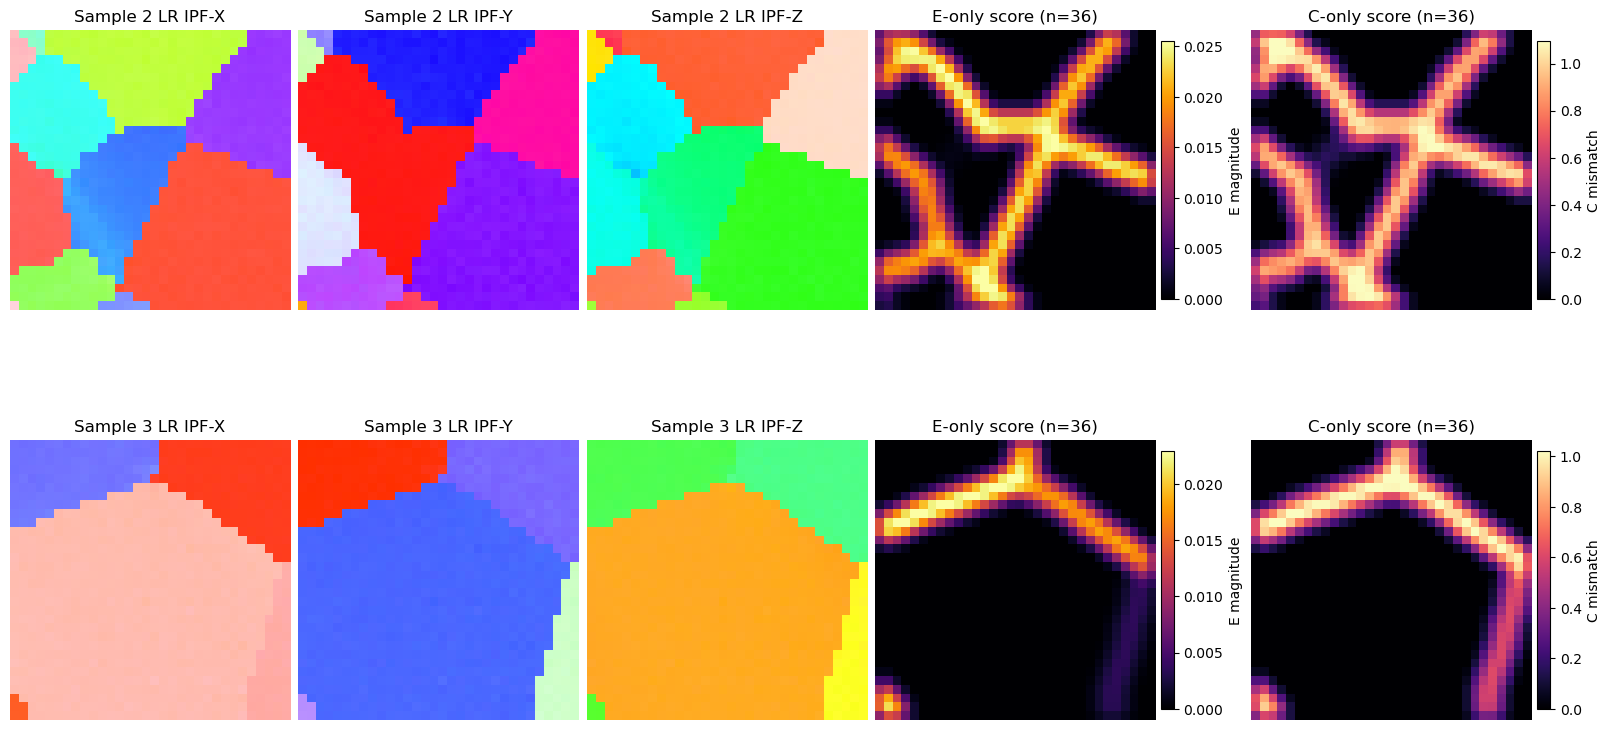

In [42]:
# Plot E and C evidence separately (irreps-only), with IPF X/Y/Z
def _aggregate_channels(ch: torch.Tensor, smooth_ks: int = 3) -> torch.Tensor:
    """ch: (S,H,W) -> robust aggregated map (H,W)."""
    S = int(ch.shape[0])
    k = max(1, int(round(0.12 * S)))
    topk_mean = torch.topk(ch, k=k, dim=0).values.mean(dim=0)
    mean_all = ch.mean(dim=0)
    out = 0.70 * topk_mean + 0.30 * mean_all
    if smooth_ks and smooth_ks > 1:
        out = F.avg_pool2d(out.unsqueeze(0).unsqueeze(0), smooth_ks, 1, smooth_ks // 2).squeeze(0).squeeze(0)
    return out

offsets_EC = [
    (-1, 0), (1, 0), (0, -1), (0, 1),
    (-1, -1), (-1, 1), (1, -1), (1, 1),
    (-2, 0), (2, 0), (0, -2), (0, 2),
]

n_ds = len(ds)
requested = list(globals().get('SAMPLE_INDICES_2', [int(SAMPLE_INDEX), int(SAMPLE_INDEX) + 1]))
sample_indices_EC = []
for idx in requested + list(range(n_ds)):
    idx_i = int(idx)
    if 0 <= idx_i < n_ds and idx_i not in sample_indices_EC:
        sample_indices_EC.append(idx_i)
    if len(sample_indices_EC) == 2:
        break

dirs = ['X', 'Y', 'Z']
rows_ec = []

with torch.no_grad():
    for sidx in sample_indices_EC:
        lr_raw_i, _ = ds[sidx]
        lr_hwc_i = normalize_quat(to_hwc_quat(lr_raw_i).to(device=device, dtype=torch.float32))
        h_i, w_i = int(lr_hwc_i.shape[0]), int(lr_hwc_i.shape[1])

        lr_flat_i = lr_hwc_i.reshape(h_i * w_i, 4)
        feat_lr_i = model.encode_a1(lr_flat_i)

        evidence_i = build_irrep_boundary_evidence_v2(
            feat_lr=feat_lr_i,
            lr_shape=(h_i, w_i),
            irreps_feat=model.irreps_a1,
            offsets=offsets_EC,
        )

        tensor_i = evidence_i['tensor']
        if tensor_i.dim() == 4:
            tensor_i = tensor_i.squeeze(0)
        names_i = evidence_i['channel_names']

        idx_E = [k for k, n in enumerate(names_i) if n.startswith('E_')]
        idx_C = [k for k, n in enumerate(names_i) if n.startswith('C_')]
        if len(idx_E) == 0 or len(idx_C) == 0:
            raise RuntimeError(f'Missing E/C channels: E={len(idx_E)}, C={len(idx_C)}')

        E_map = _aggregate_channels(tensor_i[idx_E], smooth_ks=3)
        C_map = _aggregate_channels(tensor_i[idx_C], smooth_ks=3)

        E_np = E_map.detach().cpu().numpy()
        C_np = C_map.detach().cpu().numpy()
        lr_np_i = lr_hwc_i.detach().cpu().numpy().astype(np.float32)
        ipf_by_dir = {d: render_ipf_rgb(lr_np_i, sym_class, ref_dir=d) for d in dirs}

        rows_ec.append({
            'sample_idx': int(sidx),
            'ipf_by_dir': ipf_by_dir,
            'E': E_np,
            'C': C_np,
            'nE': len(idx_E),
            'nC': len(idx_C),
        })

fig, axes = plt.subplots(len(rows_ec), 5, figsize=(16, 4.1 * len(rows_ec)), constrained_layout=True)
if len(rows_ec) == 1:
    axes = np.expand_dims(axes, axis=0)

for r, row in enumerate(rows_ec):
    sidx = row['sample_idx']

    axes[r, 0].imshow(row['ipf_by_dir']['X']); axes[r, 0].set_title(f'Sample {sidx} LR IPF-X'); axes[r, 0].axis('off')
    axes[r, 1].imshow(row['ipf_by_dir']['Y']); axes[r, 1].set_title(f'Sample {sidx} LR IPF-Y'); axes[r, 1].axis('off')
    axes[r, 2].imshow(row['ipf_by_dir']['Z']); axes[r, 2].set_title(f'Sample {sidx} LR IPF-Z'); axes[r, 2].axis('off')

    E = row['E']
    vmax_E = max(float(np.percentile(E, 99.0)), 1e-8)
    imE = axes[r, 3].imshow(E, cmap='inferno', vmin=0.0, vmax=vmax_E)
    axes[r, 3].set_title(f'E-only score (n={row["nE"]})')
    axes[r, 3].axis('off')
    cbE = fig.colorbar(imE, ax=axes[r, 3], fraction=0.046, pad=0.02)
    cbE.set_label('E magnitude')

    C = row['C']
    vmax_C = max(float(np.percentile(C, 99.0)), 1e-8)
    imC = axes[r, 4].imshow(C, cmap='magma', vmin=0.0, vmax=vmax_C)
    axes[r, 4].set_title(f'C-only score (n={row["nC"]})')
    axes[r, 4].axis('off')
    cbC = fig.colorbar(imC, ax=axes[r, 4], fraction=0.046, pad=0.02)
    cbC.set_label('C mismatch')

plt.show()


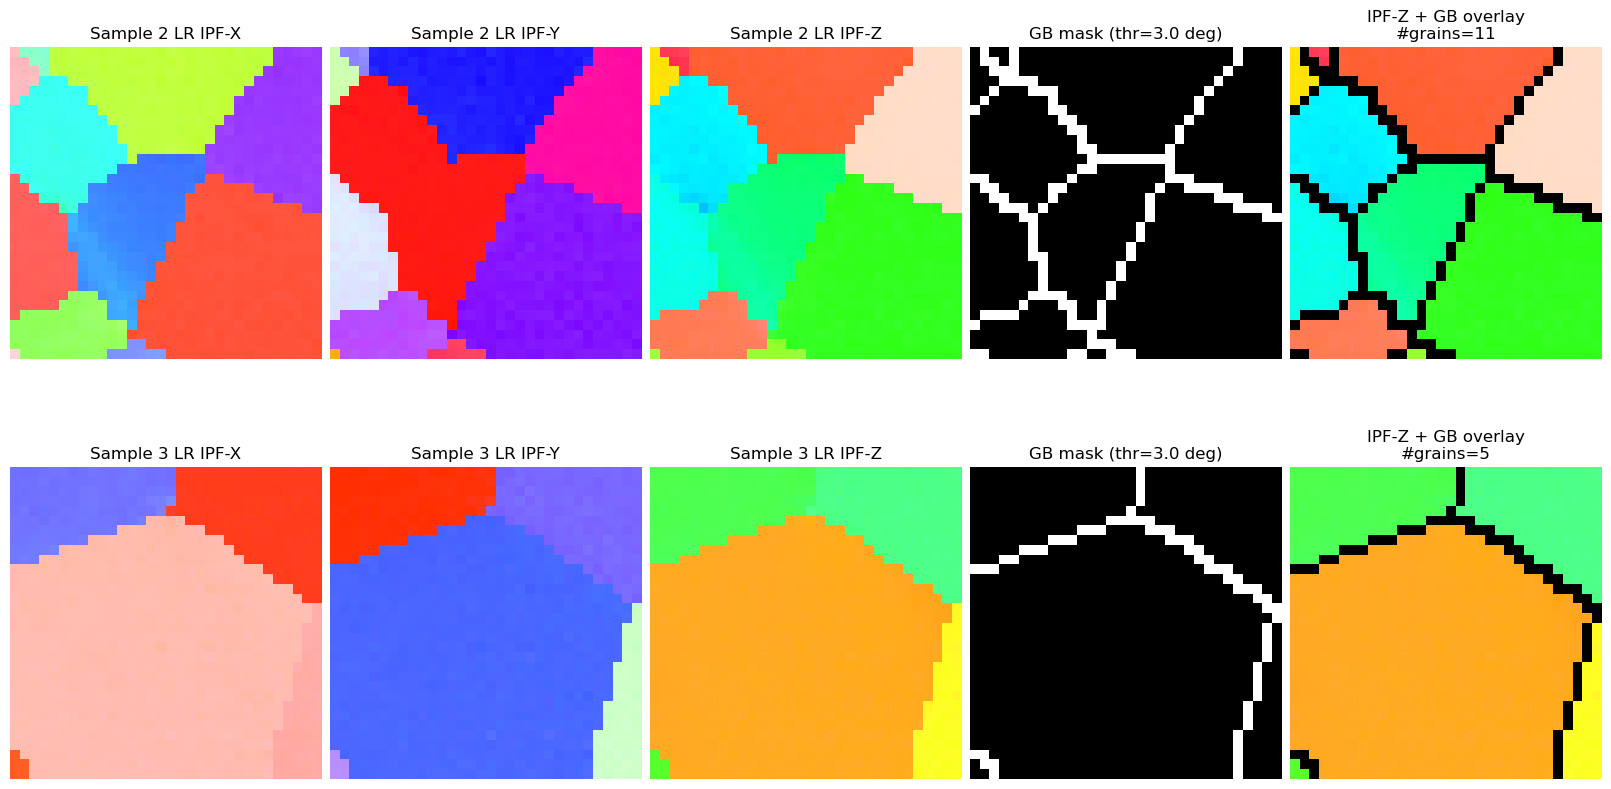

Plotted sample indices: [2, 3]


In [43]:
# Grain boundary map using segment_grains.py-style logic on the same samples
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

def _left_mult_matrix_wxyz_batch(q_syms: torch.Tensor) -> torch.Tensor:
    """q_syms: (G,4) -> left-multiply matrices (G,4,4)."""
    w, x, y, z = q_syms.unbind(dim=-1)
    r0 = torch.stack([w, -x, -y, -z], dim=-1)
    r1 = torch.stack([x,  w, -z,  y], dim=-1)
    r2 = torch.stack([y,  z,  w, -x], dim=-1)
    r3 = torch.stack([z, -y,  x,  w], dim=-1)
    return torch.stack([r0, r1, r2, r3], dim=1)

def _misorientation_angle_sym(q1: torch.Tensor, q2: torch.Tensor, sym_ops: torch.Tensor) -> torch.Tensor:
    """q1,q2: (...,4), sym_ops: (G,4,4), return radians (...,)."""
    q2var = torch.einsum('gij,...j->...gi', sym_ops, q2)
    dots = (q1.unsqueeze(-2) * q2var).sum(dim=-1).abs().clamp(0.0, 1.0)
    best = dots.max(dim=-1).values
    return 2.0 * torch.acos(best)

def _neighbor_misorientation(q_bchw: torch.Tensor, sym_ops: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    """q_bchw: (1,4,H,W) -> mis_x (H,W-1), mis_y (H-1,W)."""
    _, _, H, W = q_bchw.shape
    q_hw = q_bchw.squeeze(0).permute(1, 2, 0)
    qL = q_hw[:, :-1]
    qR = q_hw[:, 1:]
    qU = q_hw[:-1, :]
    qD = q_hw[1:, :]
    mis_x = _misorientation_angle_sym(qL, qR, sym_ops)
    mis_y = _misorientation_angle_sym(qU, qD, sym_ops)
    return mis_x, mis_y

def segment_grains_graph_like(q_bchw: torch.Tensor, sym_ops: torch.Tensor, thr_deg: float = 3.0):
    """Mirror of segment_grains.py graph segmentation."""
    mis_x, mis_y = _neighbor_misorientation(q_bchw, sym_ops)
    thr = np.deg2rad(float(thr_deg))

    mis_x_np = mis_x.detach().cpu().numpy()
    mis_y_np = mis_y.detach().cpu().numpy()
    _, _, H, W = q_bchw.shape
    N = H * W

    rows = []
    cols = []

    def idx(i, j):
        return i * W + j

    mask_x = mis_x_np <= thr
    ii, jj = np.where(mask_x)
    p1 = idx(ii, jj)
    p2 = idx(ii, jj + 1)
    rows += list(p1) + list(p2)
    cols += list(p2) + list(p1)

    mask_y = mis_y_np <= thr
    ii, jj = np.where(mask_y)
    p1 = idx(ii, jj)
    p2 = idx(ii + 1, jj)
    rows += list(p1) + list(p2)
    cols += list(p2) + list(p1)

    data = np.ones(len(rows), np.uint8)
    A = csr_matrix((data, (rows, cols)), shape=(N, N))
    nG, labels = connected_components(A, directed=False)
    return labels.reshape(H, W).astype(np.int32), int(nG)

def compute_thin_gb_mask_like(labels_np: np.ndarray, connectivity: int = 4) -> np.ndarray:
    """Mirror of segment_grains.py 1-pixel GB mask."""
    H, W = labels_np.shape
    gb = np.zeros((H, W), dtype=bool)
    gb[:, 1:] |= labels_np[:, 1:] != labels_np[:, :-1]
    gb[1:, :] |= labels_np[1:, :] != labels_np[:-1, :]
    if connectivity == 8:
        gb[1:, 1:] |= labels_np[1:, 1:] != labels_np[:-1, :-1]
        gb[1:, :-1] |= labels_np[1:, :-1] != labels_np[:-1, 1:]
    return gb

def overlay_gb_on_ipf_like(ipf_rgb: np.ndarray, gb_mask: np.ndarray) -> np.ndarray:
    img = ipf_rgb.astype(np.float32)
    if img.max() > 1.0:
        img = img / 255.0
    out = img.copy()
    out[gb_mask] = [0.0, 0.0, 0.0]
    return out

# Same 2-sample selection convention as earlier cells
n_ds = len(ds)
requested = list(globals().get('SAMPLE_INDICES_2', [int(SAMPLE_INDEX), int(SAMPLE_INDEX) + 1]))
sample_indices_gb = []
for idx in requested + list(range(n_ds)):
    idx_i = int(idx)
    if 0 <= idx_i < n_ds and idx_i not in sample_indices_gb:
        sample_indices_gb.append(idx_i)
    if len(sample_indices_gb) == 2:
        break

sym_quats = model.encoder.sym_ops.to(device=device, dtype=torch.float32)
sym_ops_4x4 = _left_mult_matrix_wxyz_batch(sym_quats).cpu()

rows = []
thr_deg = 3.0

with torch.no_grad():
    for sidx in sample_indices_gb:
        lr_raw_i, _ = ds[sidx]
        lr_hwc_i = normalize_quat(to_hwc_quat(lr_raw_i).to(device=device, dtype=torch.float32))

        q_bchw = lr_hwc_i.permute(2, 0, 1).unsqueeze(0).cpu()
        labels_np, nG = segment_grains_graph_like(q_bchw, sym_ops_4x4, thr_deg=thr_deg)
        gb_mask = compute_thin_gb_mask_like(labels_np, connectivity=4)

        lr_np_i = lr_hwc_i.detach().cpu().numpy().astype(np.float32)
        ipf_x = render_ipf_rgb(lr_np_i, sym_class, ref_dir='X')
        ipf_y = render_ipf_rgb(lr_np_i, sym_class, ref_dir='Y')
        ipf_z = render_ipf_rgb(lr_np_i, sym_class, ref_dir='Z')
        overlay_z = overlay_gb_on_ipf_like(ipf_z, gb_mask)

        rows.append({
            'sample_idx': int(sidx),
            'n_grains': int(nG),
            'ipf_x': ipf_x,
            'ipf_y': ipf_y,
            'ipf_z': ipf_z,
            'gb_mask': gb_mask,
            'overlay_z': overlay_z,
        })

fig, axes = plt.subplots(len(rows), 5, figsize=(16, 4.2 * len(rows)), constrained_layout=True)
if len(rows) == 1:
    axes = np.expand_dims(axes, axis=0)

for r, row in enumerate(rows):
    sidx = row['sample_idx']
    axes[r, 0].imshow(row['ipf_x']); axes[r, 0].set_title(f'Sample {sidx} LR IPF-X'); axes[r, 0].axis('off')
    axes[r, 1].imshow(row['ipf_y']); axes[r, 1].set_title(f'Sample {sidx} LR IPF-Y'); axes[r, 1].axis('off')
    axes[r, 2].imshow(row['ipf_z']); axes[r, 2].set_title(f'Sample {sidx} LR IPF-Z'); axes[r, 2].axis('off')

    axes[r, 3].imshow(row['gb_mask'], cmap='gray')
    axes[r, 3].set_title(f'GB mask (thr={thr_deg:.1f} deg)')
    axes[r, 3].axis('off')

    axes[r, 4].imshow(row['overlay_z'])
    axes[r, 4].set_title(f'IPF-Z + GB overlay\n#grains={row["n_grains"]}')
    axes[r, 4].axis('off')

plt.show()
print('Plotted sample indices:', sample_indices_gb)
